# Business performance analysis

**Project Description**  
Analysis of the entertainment app *Procrastinate Pro+*. Despite massive investments in advertising, the company has been experiencing losses over the past few months.

**Research Goal**  
Identify the causes of the company's losses and help it become profitable.

**Research Plan**  
- Data loading and preprocessing  
- Functions for calculating and analyzing LTV, ROI, retention, and conversion  
- Exploratory data analysis (EDA)  
- Analysis of marketing expenses  
- Evaluation of ad profitability  
- Conclusion

### Uploading and preparing data

**Load the data on visits, orders, and advertising costs from CSV files into variables.**

**File paths**  
- Visits: `/datasets/visits_info_short.csv`. [Download dataset](https://code.s3.yandex.net/datasets/visits_info_short.csv)  
- Orders: `/datasets/orders_info_short.csv`. [Download dataset](https://code.s3.yandex.net/datasets/orders_info_short.csv)  
- Costs: `/datasets/costs_info_short.csv`. [Download dataset](https://code.s3.yandex.net/datasets/costs_info_short.csv)

**Explore the data and perform preprocessing.**  
Check for any missing values or duplicates.  
Ensure that the data types in all columns match the actual values.  
Pay special attention to columns containing date and time.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from matplotlib import pyplot as plt

In [2]:
visits, orders, costs = (
    pd.read_csv('https://code.s3.yandex.net/datasets/visits_info_short.csv'),  
    pd.read_csv('https://code.s3.yandex.net/datasets/orders_info_short.csv'), 
    pd.read_csv('https://code.s3.yandex.net/datasets/costs_info_short.csv'), 
)

In [3]:
# Defining a function for the initial analysis of DataFrames
def primary_analysis(df, exclude_columns=[]):
    # Displaying the first 5 rows
    print("Head of the DataFrame:")
    display(df.head())
    
    # General information about the DataFrame
    print("Info:")
    df.info()
    
    # Description of numerical columns
    numerical_columns = df.select_dtypes(include=['number']
                                        ).columns.difference(exclude_columns)
    
    if not numerical_columns.empty:
        print()
        print("Description of numerical columns:")
        display(df[numerical_columns].describe())


In [4]:
primary_analysis(visits, exclude_columns=['User Id'])

Head of the DataFrame:


,User Id,Region,Device,Channel,Session Start,Session End
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:59,2019-05-01 00:54:25
4,349773784594,United States,Mac,organic,2019-05-01 03:33:35,2019-05-01 03:57:40


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   User Id        309901 non-null  int64 
 1   Region         309901 non-null  object
 2   Device         309901 non-null  object
 3   Channel        309901 non-null  object
 4   Session Start  309901 non-null  object
 5   Session End    309901 non-null  object
dtypes: int64(1), object(5)
memory usage: 14.2+ MB


In [5]:
primary_analysis(orders, exclude_columns=['User Id'])

Head of the DataFrame:


,User Id,Event Dt,Revenue
0,188246423999,2019-05-01 23:09:52,4.99
1,174361394180,2019-05-01 12:24:04,4.99
2,529610067795,2019-05-01 11:34:04,4.99
3,319939546352,2019-05-01 15:34:40,4.99
4,366000285810,2019-05-01 13:59:51,4.99


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User Id   40212 non-null  int64  
 1   Event Dt  40212 non-null  object 
 2   Revenue   40212 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 942.6+ KB

Description of numerical columns:


,Revenue
count,40212.000000
mean,5.370608
std,3.454208
min,4.990000
25%,4.990000
50%,4.990000
75%,4.990000
max,49.990000


In [6]:
primary_analysis(costs)

Head of the DataFrame:


,dt,Channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   Channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB

Description of numerical columns:


,costs
count,1800.000000
mean,58.609611
std,107.740223
min,0.800000
25%,6.495000
50%,12.285000
75%,33.600000
max,630.000000


In [7]:
names = ['visits', 'orders', 'costs']

# Creating a list of DataFrames
dataframes = [visits, orders, costs]

# Displaying the name of each DataFrame and the number of duplicate rows
for name, df in zip(names, dataframes):
    print(f'{name}: {df.duplicated().sum()}')


visits: 0
orders: 0
costs: 0


In [8]:
# Searching for implicit duplicates
# Creating a list of column sets to check for implicit duplicates
subset_columns = [
    ['User Id','Region', 'Device', 'Channel', 'Session Start', 'Session End'],  # For visits
    ['User Id','Event Dt', 'Revenue'],  # For orders
    ['dt', 'Channel', 'costs']  # For costs
]

# Displaying the name of each DataFrame and the number of implicit duplicates
for name, df, subset in zip(names, dataframes, subset_columns):
    print(f'{name}: {df.duplicated(subset=subset).sum()}')


visits: 0
orders: 0
costs: 0


**Conclusion:**

- **Column names** need to be converted to lowercase.

- **Data types** need to be converted to `datetime` format for the following columns: `'Session Start'` and `'Session End'` (in the `visits` table), `'Event Dt'` (in the `orders` table), and `'dt'` (in the `costs` table).

- **Missing values**: None found.

- **Duplicates**: Both explicit and implicit duplicate rows were checked — none found.

#### Time data conversion

In [9]:
# time data conversion
visits['Session Start'] = pd.to_datetime(visits['Session Start'])
visits['Session End'] = pd.to_datetime(visits['Session End'])
orders['Event Dt'] = pd.to_datetime(orders['Event Dt'])
costs['dt'] = pd.to_datetime(costs['dt']).dt.date

#### Renaming column headers (converting to lowercase):

In [10]:
# Converting column names to lowercase and replacing spaces with underscores for all DataFrames
for df in dataframes:
    df.columns = [x.lower().replace(' ', '_') for x in df.columns]

# Checking column names after the change
for name, df in zip(names, dataframes):
    print(f'{name} columns:', df.columns)


visits columns: Index(['user_id', 'region', 'device', 'channel', 'session_start',
       'session_end'],
      dtype='object')
orders columns: Index(['user_id', 'event_dt', 'revenue'], dtype='object')
costs columns: Index(['dt', 'channel', 'costs'], dtype='object')


**Conclusion:**

- **Column names** have been converted to lowercase;

- **Data types**: columns containing date information have been converted to `datetime` format.

### Define functions for calculating and analyzing LTV, ROI, retention, and conversion.

You are allowed to use the functions introduced in the theoretical lessons.

These are the functions for calculating metric values:

- `get_profiles()` — to create user profiles  
- `get_retention()` — to calculate Retention Rate  
- `get_conversion()` — to calculate conversion  
- `get_ltv()` — to calculate LTV

And functions for visualizations:

- `filter_data()` — to smooth the data  
- `plot_retention()` — to plot the Retention Rate  
- `plot_conversion()` — to plot conversion  
- `plot_ltv_roi()` — to visualize LTV and ROI

#### Function for creating user profiles

In [11]:

def get_profiles(sessions, orders, events, ad_costs, event_names=[]):
    # find parameters of the first visits
    profiles = (
        sessions.sort_values(by=['user_id', 'session_start'])
        .groupby('user_id')
        .agg(
            {
                'session_start': 'first',
                'channel': 'first',
                'device': 'first',
                'region': 'first',
            }
        )
        .rename(columns={'session_start': 'first_ts'})
        .reset_index()
    )

    # for cohort analysis, define the date of the first visit
    # and the first day of the month in which this visit occurred
    profiles['dt'] = profiles['first_ts'].dt.date
    profiles['month'] = profiles['first_ts'].values.astype('datetime64[M]')

    # add a flag for paying users
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())

    # add flags for all events from event_names
    for event in event_names:
        if event in events['event_name'].unique():
            profiles[event] = profiles['user_id'].isin(
                events.query('event_name == @event')['user_id'].unique()
            )

    # calculate number of unique users
    # with the same acquisition source and acquisition date
    new_users = (
        profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
        .rename(columns={'user_id': 'unique_users'})
        .reset_index()
    )

    # merge ad spend with the number of acquired users
    ad_costs = ad_costs.merge(new_users, on=['dt', 'channel'], how='left')

    # divide ad spend by number of acquired users
    ad_costs['acquisition_cost'] = ad_costs['costs'] / ad_costs['unique_users']

    # add acquisition cost to profiles
    profiles = profiles.merge(
        ad_costs[['dt', 'channel', 'acquisition_cost']],
        on=['dt', 'channel'],
        how='left',
    )

    # acquisition cost for organic users is zero
    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)

    return profiles


#### Function for calculating retention

In [12]:
def get_retention(
    profiles,
    sessions,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):
    # add 'payer' column to the dimensions list
    dimensions = ['payer'] + dimensions

    # exclude users who did not "live" to the analysis horizon
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # prepare raw data for retention calculation
    result_raw = result_raw.merge(
        sessions[['user_id', 'session_start']], on='user_id', how='left'
    )
    result_raw['lifetime'] = (
        result_raw['session_start'] - result_raw['first_ts']
    ).dt.days

    # function to group table by desired dimensions
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # get the retention table
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # get the time-based retention table
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # return both retention tables and raw data
    return result_raw, result_grouped, result_in_time


#### Conversion calculation function

In [13]:
def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):
    # exclude users who did not "live" to the analysis horizon
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # determine the date and time of the first purchase for each user
    first_purchases = (
        purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index()
    )

    # merge purchase data into user profiles
    result_raw = result_raw.merge(
        first_purchases[['user_id', 'event_dt']], on='user_id', how='left'
    )

    # calculate lifetime for each purchase
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    # group by cohort if dimensions list is empty
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users' 
        dimensions = dimensions + ['cohort']

    # function to group table by desired dimensions
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        result = result.fillna(0).cumsum(axis=1)
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # divide each cell in the row by the cohort size
        # to get the conversion rate
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # get the conversion table
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # for the time-based conversion table, remove 'cohort' from dimensions
    if 'cohort' in dimensions: 
        dimensions = []

    # get the time-based conversion table
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # return both conversion tables and raw data
    return result_raw, result_grouped, result_in_time


#### Function for calculating LTV and ROI

In [14]:
def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):
    # exclude users who did not "live" to the analysis horizon
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # merge purchase data into profiles
    result_raw = result_raw.merge(
        purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left'
    )

    # calculate user lifetime for each purchase
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    # group by cohort if dimensions list is empty
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # function to group by desired dimensions
    def group_by_dimensions(df, dims, horizon_days):
        # create "triangular" revenue table
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum'
        )
        # calculate cumulative revenue
        result = result.fillna(0).cumsum(axis=1)

        # calculate cohort sizes
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )

        # merge revenue table with cohort sizes
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)

        # calculate LTV: divide each cell by the cohort size
        result = result.div(result['cohort_size'], axis=0)

        # keep only lifetimes within the analysis horizon
        result = result[['cohort_size'] + list(range(horizon_days))]

        # restore cohort sizes
        result['cohort_size'] = cohort_sizes

        # build a dataframe with user data and CAC values, including dimensions
        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()

        # calculate average CAC for each cohort
        cac = (
            cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'})
        )

        # calculate ROI: divide LTV by CAC
        roi = result.div(cac['cac'], axis=0)

        # remove rows with infinite ROI
        roi = roi[~roi['cohort_size'].isin([np.inf])]

        # restore cohort sizes in ROI table
        roi['cohort_size'] = cohort_sizes

        # add CAC to ROI table
        roi['cac'] = cac['cac']

        # final ROI table: cohort size, CAC, and ROI by lifetime
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]

        # return LTV and ROI tables
        return result, roi

    # get LTV and ROI tables
    result_grouped, roi_grouped = group_by_dimensions(
        result_raw, dimensions, horizon_days
    )

    # for dynamic tables, remove 'cohort' from dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # get dynamic LTV and ROI tables
    result_in_time, roi_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    return (
        result_raw,      # raw data
        result_grouped,  # LTV table
        result_in_time,  # LTV dynamics
        roi_grouped,     # ROI table
        roi_in_time      # ROI dynamics
    )


#### Function for smoothing the frame

In [15]:
def filter_data(df, window):
    # apply moving average to each column
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean() 
    return df


#### Function for visualizing retention

In [16]:
def plot_retention(retention, retention_history, horizon, window=7):

    # set the plot grid size
    plt.figure(figsize=(15, 10))

    # exclude cohort sizes and day 0 retention
    retention = retention.drop(columns=['cohort_size', 0])
    # in the history table, keep only the desired lifetime
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # if the retention table is indexed only by 'payer',
    # add a second feature — 'cohort'
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    # the plot grid: two columns, two rows, four cells
    # top left: retention curves for paying users
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid=True, ax=ax1
    )
    plt.legend()
    plt.xlabel('Lifetime')
    plt.title('Retention of Paying Users')

    # top right: retention curves for non-paying users
    # y-axis shared with top left plot
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    retention.query('payer == False').droplevel('payer').T.plot(
        grid=True, ax=ax2
    )
    plt.legend()
    plt.xlabel('Lifetime')
    plt.title('Retention of Non-Paying Users')

    # bottom left: retention dynamics of paying users
    ax3 = plt.subplot(2, 2, 3)
    # get column names for pivot
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    # filter data and plot
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Acquisition Date')
    plt.title(
        'Retention Dynamics of Paying Users on Day {}'.format(
            horizon
        )
    )

    # bottom right: retention dynamics of non-paying users
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    # filter data and plot
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Acquisition Date')
    plt.title(
        'Retention Dynamics of Non-Paying Users on Day {}'.format(
            horizon
        )
    )

    plt.tight_layout()
    plt.show()


#### Conversion visualization function

In [17]:
def plot_conversion(conversion, conversion_history, horizon, window=7):

    # set the size of the plot grid
    plt.figure(figsize=(15, 5))

    # remove cohort size column
    conversion = conversion.drop(columns=['cohort_size'])
    # keep only the required lifetime column in the history table
    conversion_history = conversion_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # first plot — conversion curves
    ax1 = plt.subplot(1, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Lifetime')
    plt.title('User Conversion')

    # second plot — conversion dynamics
    ax2 = plt.subplot(1, 2, 2, sharey=ax1)
    columns = [
        # columns for the pivot table will be all index columns except date
        name for name in conversion_history.index.names if name not in ['dt']
    ]
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Acquisition Date')
    plt.title('Conversion Dynamics on Day {}'.format(horizon))

    plt.tight_layout()
    plt.show()


#### Function for LTV and ROI visualization

In [18]:
def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window=7):

    # set up the plot grid
    plt.figure(figsize=(20, 10))

    # remove cohort sizes from the LTV table
    ltv = ltv.drop(columns=['cohort_size'])
    # in the LTV history table, keep only the desired lifetime
    ltv_history = ltv_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # extract acquisition cost (CAC) into a separate DataFrame
    cac_history = roi_history[['cac']]

    # remove cohort sizes and CAC from the ROI table
    roi = roi.drop(columns=['cohort_size', 'cac'])
    # in the ROI history table, keep only the desired lifetime
    roi_history = roi_history.drop(columns=['cohort_size', 'cac'])[
        [horizon - 1]
    ]

    # First plot — LTV curves
    ax1 = plt.subplot(2, 3, 1)
    ltv.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Lifetime')
    plt.title('LTV')

    # Second plot — LTV dynamics
    ax2 = plt.subplot(2, 3, 2, sharey=ax1)
    # pivot table columns will be all index columns except date
    columns = [name for name in ltv_history.index.names if name not in ['dt']]
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Acquisition Date')
    plt.title('LTV Dynamics on Day {}'.format(horizon))

    # Third plot — CAC dynamics
    ax3 = plt.subplot(2, 3, 3, sharey=ax1)
    columns = [name for name in cac_history.index.names if name not in ['dt']]
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Acquisition Date')
    plt.title('Customer Acquisition Cost (CAC) Dynamics')

    # Fourth plot — ROI curves
    ax4 = plt.subplot(2, 3, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Break-even level')
    plt.legend()
    plt.xlabel('Lifetime')
    plt.title('ROI')

    # Fifth plot — ROI dynamics
    ax5 = plt.subplot(2, 3, 5, sharey=ax4)
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Break-even level')
    plt.xlabel('Acquisition Date')
    plt.title('ROI Dynamics on Day {}'.format(horizon))

    plt.tight_layout()
    plt.show()


### Exploratory Data Analysis

- Create user profiles. Determine the **minimum and maximum acquisition dates** of users.  
- Identify which **countries** users come from, and which country has the **highest number of paying users**. Build a table showing the number of users and the **share of paying users** from each country.  
- Investigate the **devices** used by customers and which devices are **preferred by paying users**. Build a table showing the number of users and the **share of paying users** for each device.  
- Analyze the **advertising sources** of user acquisition and identify the **channels with the most paying users**. Build a table showing the number of users and the **share of paying users** for each acquisition channel.

After each section, formulate your conclusions.

#### User profiles. Minimum and maximum dates of attraction.

In [19]:
# getting user profiles
events=[]
profiles = get_profiles(visits, orders, events, costs) 

In [20]:
primary_analysis(profiles, exclude_columns=['user_id'])

Head of the DataFrame:


,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost
0,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05-01,True,1.088172
1,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,2019-07-01,False,1.107237
2,6085896,2019-10-01 09:58:33,organic,iPhone,France,2019-10-01,2019-10-01,False,0.000000
3,22593348,2019-08-22 21:35:48,AdNonSense,PC,Germany,2019-08-22,2019-08-01,False,0.988235
4,31989216,2019-10-02 00:07:44,YRabbit,iPhone,United States,2019-10-02,2019-10-01,False,0.230769


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150008 entries, 0 to 150007
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           150008 non-null  int64         
 1   first_ts          150008 non-null  datetime64[ns]
 2   channel           150008 non-null  object        
 3   device            150008 non-null  object        
 4   region            150008 non-null  object        
 5   dt                150008 non-null  object        
 6   month             150008 non-null  datetime64[s] 
 7   payer             150008 non-null  bool          
 8   acquisition_cost  150008 non-null  float64       
dtypes: bool(1), datetime64[ns](1), datetime64[s](1), float64(1), int64(1), object(4)
memory usage: 9.3+ MB

Description of numerical columns:


,acquisition_cost
count,150008.000000
mean,0.703278
std,0.954097
min,0.000000
25%,0.000000
50%,0.247500
75%,1.108943
max,3.715385


In [21]:
# Determine the minimum and maximum user acquisition dates
print('Min:', profiles['first_ts'].min())
print('Min:', profiles['first_ts'].max())

Min: 2019-05-01 00:00:41
Min: 2019-10-27 23:59:04


**Conclusion:**

- User profiles have been created.  
The earliest user acquisition date is May 1, 2019, and the latest is October 27, 2019, which matches the period specified in the project description.

#### Identify which countries users come from and which country has the highest number of paying users.  
Build a table showing the number of users and the share of paying users from each country.

In [22]:
profiles.groupby('region').agg({'user_id': 'nunique', 'payer': ['mean', 'sum']})

user_id     payer      
              nunique      mean   sum
region                               
France          17450  0.037994   663
Germany         14981  0.041119   616
UK              17575  0.039829   700
United States  100002  0.069019  6902

**Conclusion:**  

- The largest number of users comes from the United States (100,002), and it also has the highest share of paying users — 6.90%.  
- The UK is the second-largest in terms of user count with 17,575 users and a paying user share of 3.98%.  
- Germany has 14,981 users, with 4.11% of them being paying users.  
- France has 17,450 users and the lowest share of paying users — 3.80%.

#### What devices do customers use (especially paying ones)

In [23]:
profiles.groupby('device').agg({'user_id': 'nunique', 'payer': ['mean', 'sum']})

user_id     payer      
        nunique      mean   sum
device                         
Android   35032  0.058518  2050
Mac       30042  0.063644  1912
PC        30455  0.050468  1537
iPhone    54479  0.062079  3382

**Conclusion:**  

- iPhone users form the largest audience (54,479) and have a high share of paying users — 6.21%.  
- However, Mac users, despite a smaller number (30,042), have the highest share of paying users — 6.36%.  
- Android users: 35,032 people, with a paying user share of 5.85%.  
- PC users: 30,455 total, with a paying user share of 5.05%.

#### Advertising acquisition sources

In [24]:
# Build a table showing the number of users and the share of paying users for each acquisition channel.
profiles.groupby('channel').agg({'user_id': 'nunique', 'payer': ['mean', 'sum']}
                               ).sort_values(by=('user_id', 'nunique'), ascending=False)

user_id     payer      
                   nunique      mean   sum
channel                                   
organic              56439  0.020553  1160
FaceBoom             29144  0.122049  3557
TipTop               19561  0.096007  1878
OppleCreativeMedia    8605  0.027077   233
LeapBob               8553  0.030633   262
WahooNetBanner        8553  0.052964   453
RocketSuperAds        4448  0.079137   352
MediaTornado          4364  0.035747   156
YRabbit               4312  0.038265   165
AdNonSense            3880  0.113402   440
lambdaMediaAds        2149  0.104700   225

**Conclusion:**  

- The largest number of users came through organic traffic — 56,439. However, this channel has a very low share of paying users — only 2.05%. This is likely because organic traffic is less controllable, unlike paid channels which are optimized to attract paying users.

- FaceBoom attracted 29,144 users, making it the second most popular channel. It has the highest share of paying users — 12.2%, making it the most effective channel.

- TipTop brought in 19,561 users with a paying user share of 9.60% (1,878), which is also a strong performance.  
AdNonSense and lambdaMediaAds have among the lowest numbers of acquired users (3,880 and 2,149), yet their shares of paying users are high — 11.34% and 10.47%, respectively.

### Marketing

- Calculate the total marketing spend.  
- Determine how expenses are distributed across advertising sources — i.e., how much was spent on each channel.  
- Create a plot visualizing the weekly spending dynamics over time for each channel. Then, on a separate chart, visualize the monthly spending dynamics over time for each channel.  
- Find out the average cost of acquiring one user (CAC) for each source using user profiles.

Write intermediate conclusions after each step.

#### Total marketing expenses

In [25]:
print("Total marketing expenses:", profiles['acquisition_cost'].sum().round(2))

Total marketing expenses: 105497.3


#### Distribution of expenses by advertising sources

In [26]:
# Determine how expenses are distributed across advertising sources
profiles.groupby('channel').agg({'acquisition_cost': 'sum'}
                               ).sort_values(by=('acquisition_cost'), ascending=False)

,acquisition_cost
channel,
TipTop,54751.30
FaceBoom,32445.60
WahooNetBanner,5151.00
AdNonSense,3911.25
OppleCreativeMedia,2151.25
RocketSuperAds,1833.00
LeapBob,1797.60
lambdaMediaAds,1557.60
MediaTornado,954.48


**Conclusion:**

- TipTop is the largest source of marketing expenses, with 54,751.30 units spent — significantly more than other advertising channels.

- FaceBoom ranks second with 32,445.60 units.

- WahooNetBanner and AdNonSense have moderate expenses of 5,151.00 and 3,911.25 units respectively.

- OppleCreativeMedia, RocketSuperAds, and LeapBob each had spending in the range of 1,800–2,150 units.  
lambdaMediaAds, MediaTornado, and YRabbit had the lowest expenditures, ranging from 944.22 to 1,557.60 units.

- Organic has no associated user acquisition costs (traffic comes through natural search or unpaid referrals).

#### Charts visualizing the dynamics of spending changes over time

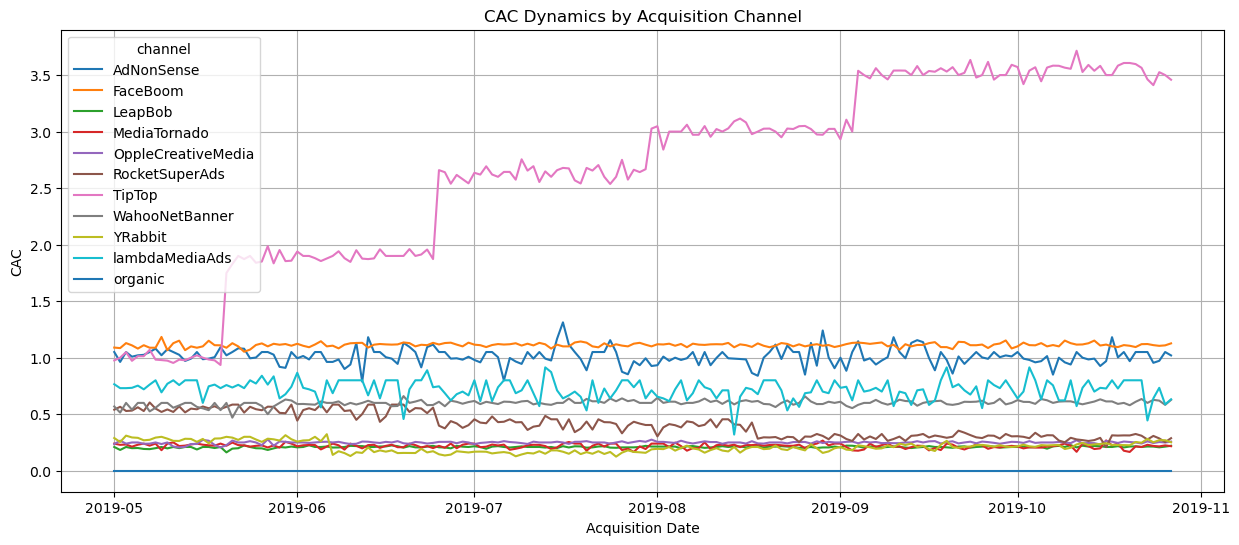

In [27]:
# Plotting the history of CAC changes by acquisition channel

profiles.pivot_table(
    index='dt', columns='channel', values='acquisition_cost', aggfunc='mean'
).plot(grid=True, figsize=(15, 6))
plt.ylabel('CAC')
plt.xlabel('Acquisition Date')
plt.title('CAC Dynamics by Acquisition Channel')
plt.show()


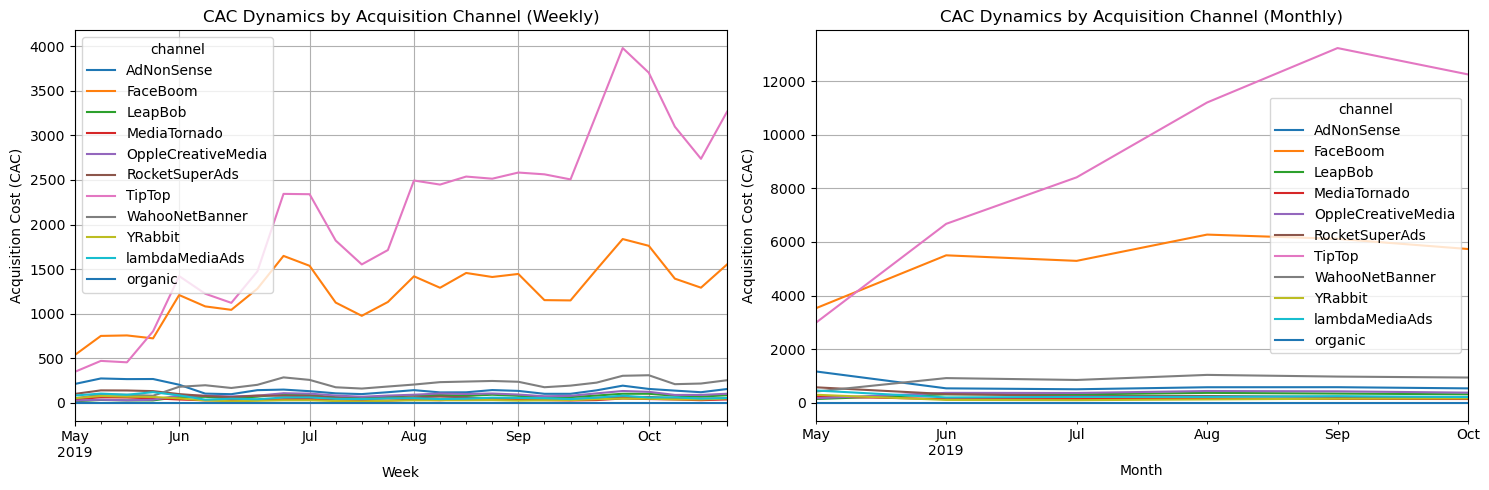

In [28]:
# Convert the 'dt' column to datetime format, as it was mistakenly of type object
profiles['dt'] = pd.to_datetime(profiles['dt'])

# Create figure and axes for two plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Group data by weeks
weekly_expenses = profiles.pivot_table(
    index=pd.Grouper(key='dt', freq='W'),  # Group by weeks
    columns='channel', 
    values='acquisition_cost', 
    aggfunc='sum'  # Sum acquisition costs for each week
)

# Group data by months
monthly_expenses = profiles.pivot_table(
    index=pd.Grouper(key='dt', freq='ME'),  # Group by month end
    columns='channel', 
    values='acquisition_cost', 
    aggfunc='sum'
)

# First plot (weekly)
weekly_expenses.plot(ax=axes[0], grid=True)
axes[0].set_ylabel('Acquisition Cost (CAC)')
axes[0].set_xlabel('Week')
axes[0].set_title('CAC Dynamics by Acquisition Channel (Weekly)')

# Second plot (monthly)
monthly_expenses.plot(ax=axes[1], grid=True)
axes[1].set_ylabel('Acquisition Cost (CAC)')
axes[1].set_xlabel('Month')
axes[1].set_title('CAC Dynamics by Acquisition Channel (Monthly)')

# Show the plots
plt.tight_layout()
plt.show()


TipTop and FaceBoom are the main sources with the highest acquisition costs. To better examine the spending fluctuations across the other channels, we’ll limit the value range.

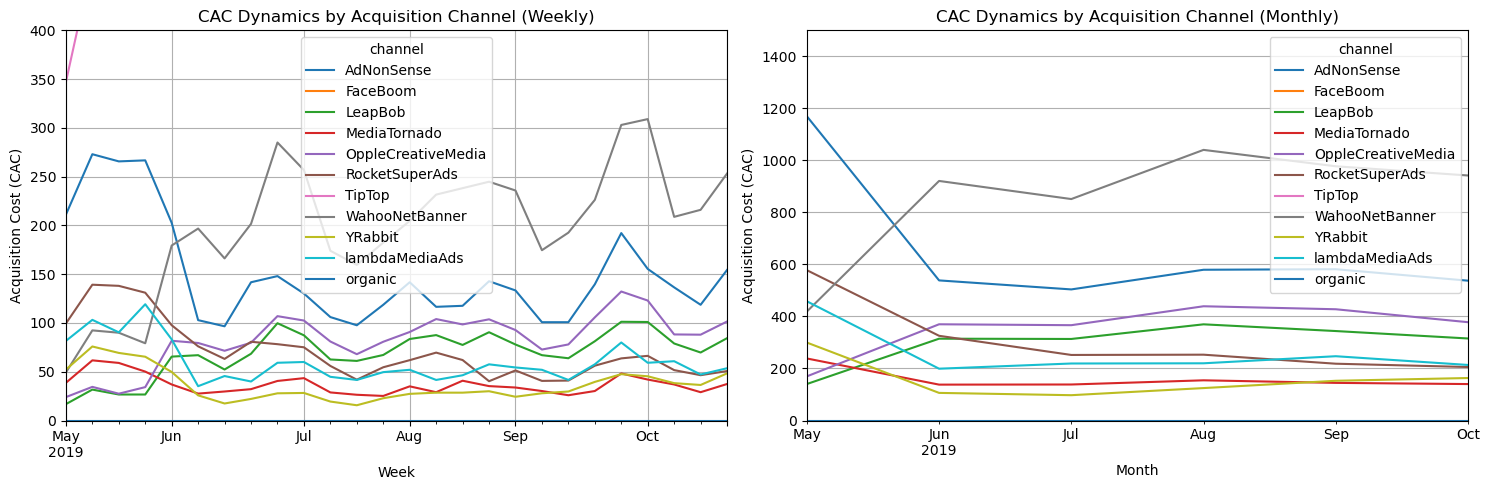

In [29]:
# Create figure and axes for two plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# First plot (weekly)
weekly_expenses.plot(ax=axes[0], grid=True)
axes[0].set_ylabel('Acquisition Cost (CAC)')
axes[0].set_xlabel('Week')
axes[0].set_title('CAC Dynamics by Acquisition Channel (Weekly)')
axes[0].set_ylim(0, 400)  # Limit Y-axis values to 400

# Second plot (monthly)
monthly_expenses.plot(ax=axes[1], grid=True)
axes[1].set_ylabel('Acquisition Cost (CAC)')
axes[1].set_xlabel('Month')
axes[1].set_title('CAC Dynamics by Acquisition Channel (Monthly)')
axes[1].set_ylim(0, 1500)  # Limit Y-axis values to 1500

# Show the plots
plt.tight_layout()
plt.show()

**Conclusion:** TipTop and FaceBoom are the primary sources with the highest acquisition costs.  
TipTop shows a sharp increase in spending throughout the entire period. There are significant weekly fluctuations, with several peaks — particularly noticeable in June and September — which may indicate active advertising campaigns during those times.  
FaceBoom displays more consistent spending with minor variations.  
Other channels lag significantly in terms of spending. Among them, AdNonSense and WahooNetBanner have the highest costs.

#### Cost of acquiring a single user (CAC) from each source

In [30]:
# Acquisition costs for organic users are zero, so we’ll exclude them.
pay_profiles = profiles.query('channel != "organic"')

In [31]:
cac = pay_profiles.groupby('channel').agg({'acquisition_cost': 'mean'}
                               ).rename(columns={'acquisition_cost': 'cac'}
                                       ).sort_values(by=('cac'), ascending=False)
cac

,cac
channel,
TipTop,2.799003
FaceBoom,1.113286
AdNonSense,1.008054
lambdaMediaAds,0.724802
WahooNetBanner,0.602245
RocketSuperAds,0.412095
OppleCreativeMedia,0.250000
YRabbit,0.218975
MediaTornado,0.218717


**Conclusion:** TipTop has the highest average customer acquisition cost (CAC) — 2.80. This is significantly higher than other channels, which may indicate either a high advertising cost in this channel or low user conversion rates.  
FaceBoom and AdNonSense also have relatively high CAC values — 1.11 and 1.01, respectively.  
lambdaMediaAds, WahooNetBanner, and other channels have moderate to low CAC levels.

### Assess Advertising Profitability

Using LTV, ROI, and CAC charts, analyze the effectiveness of advertising campaigns. Assume today's date is **November 1, 2019**, and according to the business plan, users are expected to pay off **no later than two weeks after acquisition**. Decide independently whether to include **organic users** in the analysis.

- Analyze advertising profitability using **LTV and ROI graphs**, along with the **dynamics of LTV, CAC, and ROI**.
- Check **user conversion** and its dynamics. Do the same for **user retention**. Build and study the corresponding graphs.
- Analyze advertising profitability **by device**. Create graphs for LTV and ROI, as well as their dynamics.
- Analyze advertising profitability **by country**. Create graphs for LTV and ROI, as well as their dynamics.
- Analyze advertising profitability **by advertising channel**. Create graphs for LTV and ROI, as well as their dynamics.
- Answer the following questions:
    - Is the advertising campaign overall **profitable**?
    - Which **devices**, **countries**, or **advertising channels** might be **negatively affecting profitability**?
    - What might be the **causes** of low ROI?

Write a conclusion describing possible causes of the issues discovered and provide **intermediate recommendations** for the marketing team.

In [32]:
# Set the necessary parameters  
observation_date = datetime(2019, 11, 1).date()  # analysis date  
horizon_days = 14  # analysis horizon  


#### Advertising profitability based on LTV and ROI graphs, as well as the dynamics of LTV, CAC, and ROI

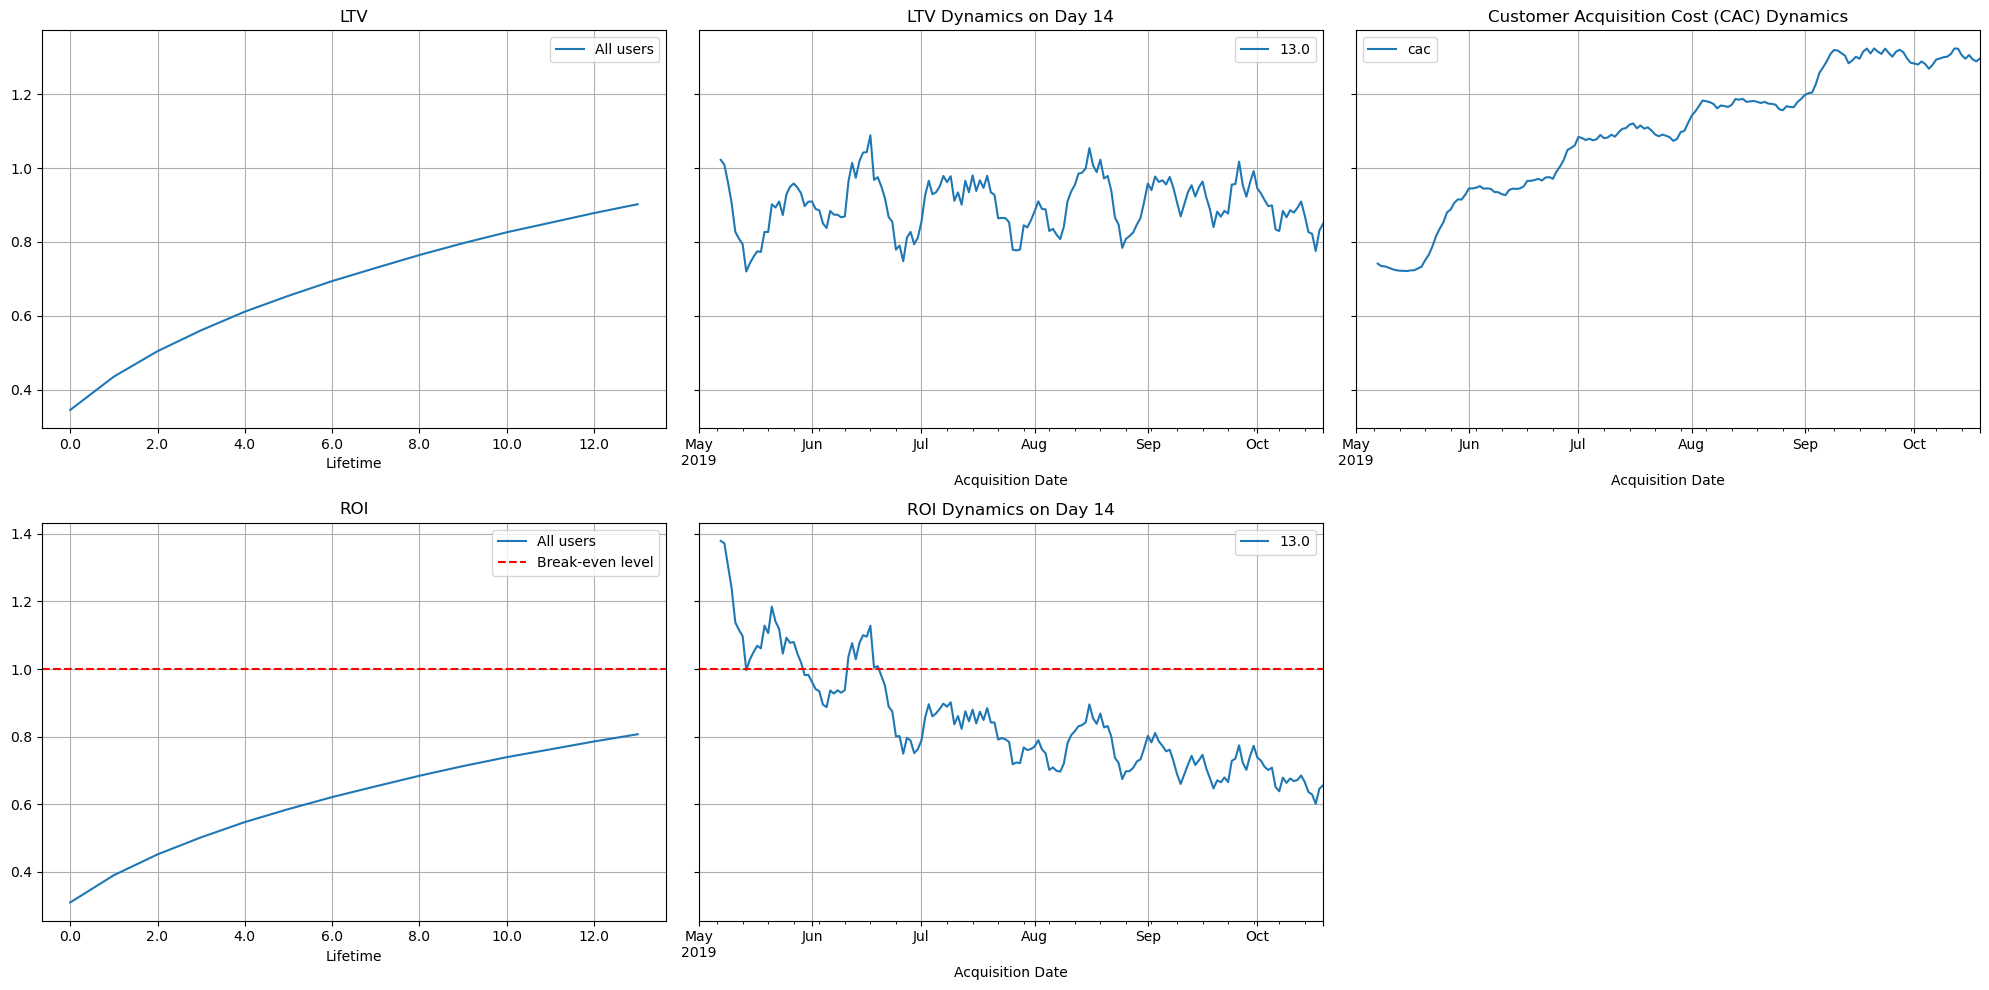

In [33]:
# Calculate LTV and ROI
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    pay_profiles, orders, observation_date, horizon_days, dimensions=[],
    ignore_horizon=False)

# Plot the graphs
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

**Conclusion:**

- LTV is relatively stable, indicating that the quality of acquired users has not deteriorated.

- Advertising is **not profitable**. The ROI at the end of the observed period is **80%**.

- CAC has increased significantly, with a sharp spike in June followed by a more gradual rise. This suggests that the ROI issue may be linked to increased competition in the advertising channel or a rise in the ad budget.

- ROI dynamics by lifetime are declining. While LTV remains fairly stable, CAC has been increasing from May through the end of October. The rise in CAC since June has had a **negative impact on ROI**.

#### User conversion

In [34]:
# Calculate Conversion Rate
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    pay_profiles, orders, observation_date, horizon_days)

conversion_raw  # conversion table


,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost,event_dt,lifetime,cohort
0,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05-01,True,1.088172,2019-05-07 20:59:09,0.0,All users
1,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,2019-07-01,False,1.107237,NaT,NaN,All users
2,22593348,2019-08-22 21:35:48,AdNonSense,PC,Germany,2019-08-22,2019-08-01,False,0.988235,NaT,NaN,All users
3,31989216,2019-10-02 00:07:44,YRabbit,iPhone,United States,2019-10-02,2019-10-01,False,0.230769,NaT,NaN,All users
4,46006712,2019-06-30 03:46:29,AdNonSense,Android,France,2019-06-30,2019-06-01,True,1.008000,2019-06-30 03:46:52,0.0,All users
...,...,...,...,...,...,...,...,...,...,...,...,...
88639,999942424543,2019-05-24 21:03:26,TipTop,iPhone,United States,2019-05-24,2019-05-01,False,1.900000,NaT,NaN,All users
88640,999949280903,2019-08-12 06:47:27,FaceBoom,Mac,United States,2019-08-12,2019-08-01,False,1.117838,NaT,NaN,All users
88641,999956196527,2019-09-28 08:33:02,TipTop,iPhone,United States,2019-09-28,2019-09-01,False,3.500000,NaT,NaN,All users
88642,999976332130,2019-07-23 02:57:06,TipTop,iPhone,United States,2019-07-23,2019-07-01,False,2.600000,NaT,NaN,All users


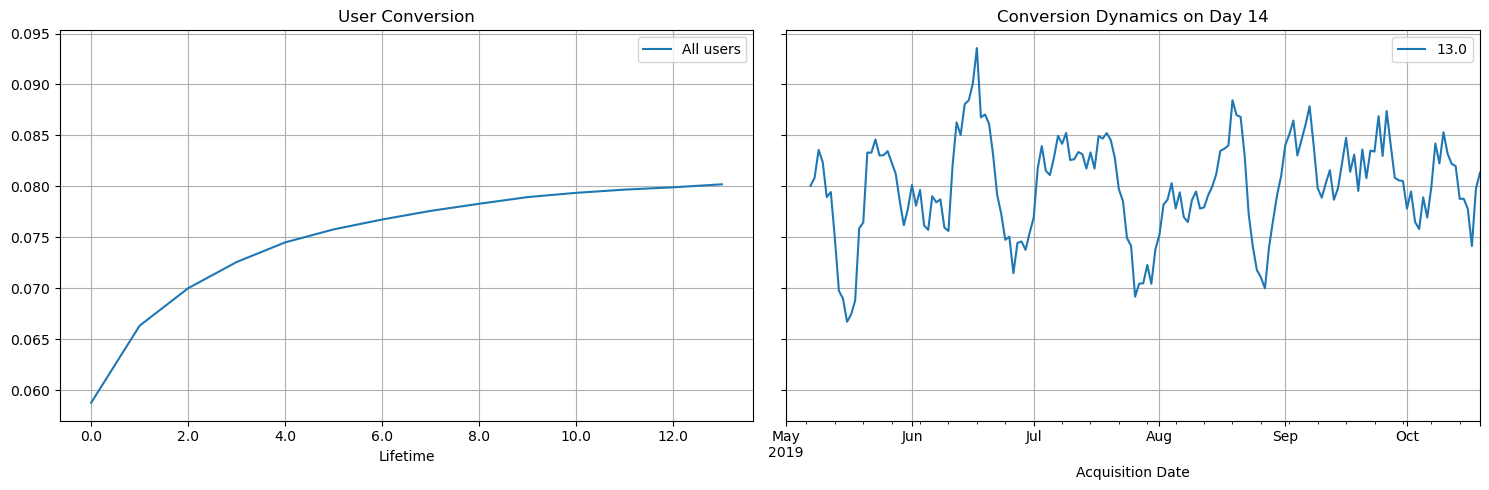

In [35]:
# Plot the graphs
plot_conversion(conversion_grouped, conversion_history, horizon_days)

**Conclusion:**

- Most users convert within the first few days after acquisition, after which the conversion rate slows down but continues to grow. The final conversion rate reaches around **8%**.

- Significant fluctuations in conversion dynamics on the 14th day may indicate a need to analyze **external factors** affecting user behavior and to **adjust marketing strategies** in order to stabilize the conversion rate.

#### User retention

In [36]:
# Calculate Retention Rate

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days)

retention_raw  # retention table


,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost,session_start,lifetime
0,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05-01,True,1.088172,2019-05-07 20:58:57,0
1,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05-01,True,1.088172,2019-05-08 06:00:42,0
2,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05-01,True,1.088172,2019-05-09 07:33:16,1
3,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,2019-07-01,False,1.107237,2019-07-09 12:46:07,0
4,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,2019-07-01,False,1.107237,2019-07-10 22:27:24,1
...,...,...,...,...,...,...,...,...,...,...,...
297803,999976332130,2019-07-23 02:57:06,TipTop,iPhone,United States,2019-07-23,2019-07-01,False,2.600000,2019-07-23 02:57:06,0
297804,999979924135,2019-09-28 21:28:09,MediaTornado,PC,United States,2019-09-28,2019-09-01,False,0.205714,2019-09-28 21:28:09,0
297805,999979924135,2019-09-28 21:28:09,MediaTornado,PC,United States,2019-09-28,2019-09-01,False,0.205714,2019-10-04 07:37:05,5
297806,999999563947,2019-10-18 19:57:25,organic,iPhone,United States,2019-10-18,2019-10-01,False,0.000000,2019-10-18 19:57:25,0


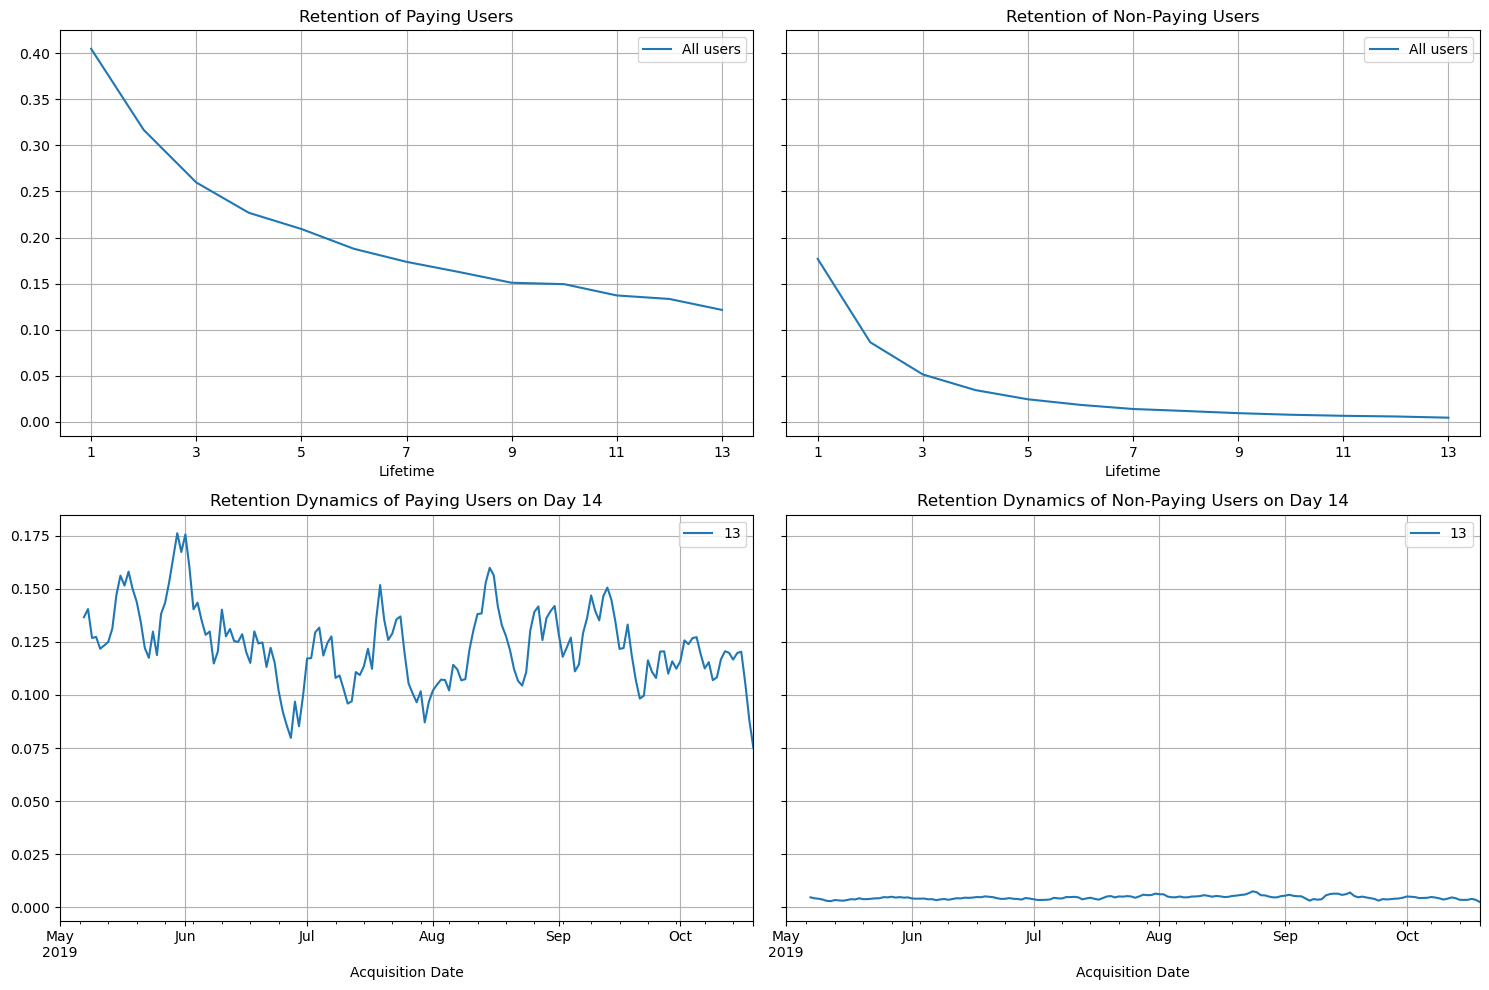

In [37]:
# Plot the graphs
plot_retention(retention_grouped, retention_history, horizon_days) 

**Conclusion:**

- **Paying users** show higher and longer retention compared to non-paying users.

- The retention dynamics chart for paying users shows periods of **higher retention** (e.g., in June and mid-August) and periods of **lower retention** (e.g., also in June, August, and October), indicating fluctuations that may warrant further analysis.

#### Analyze advertising profitability by device. Plot LTV and ROI charts, as well as dynamics of LTV, CAC, and ROI.

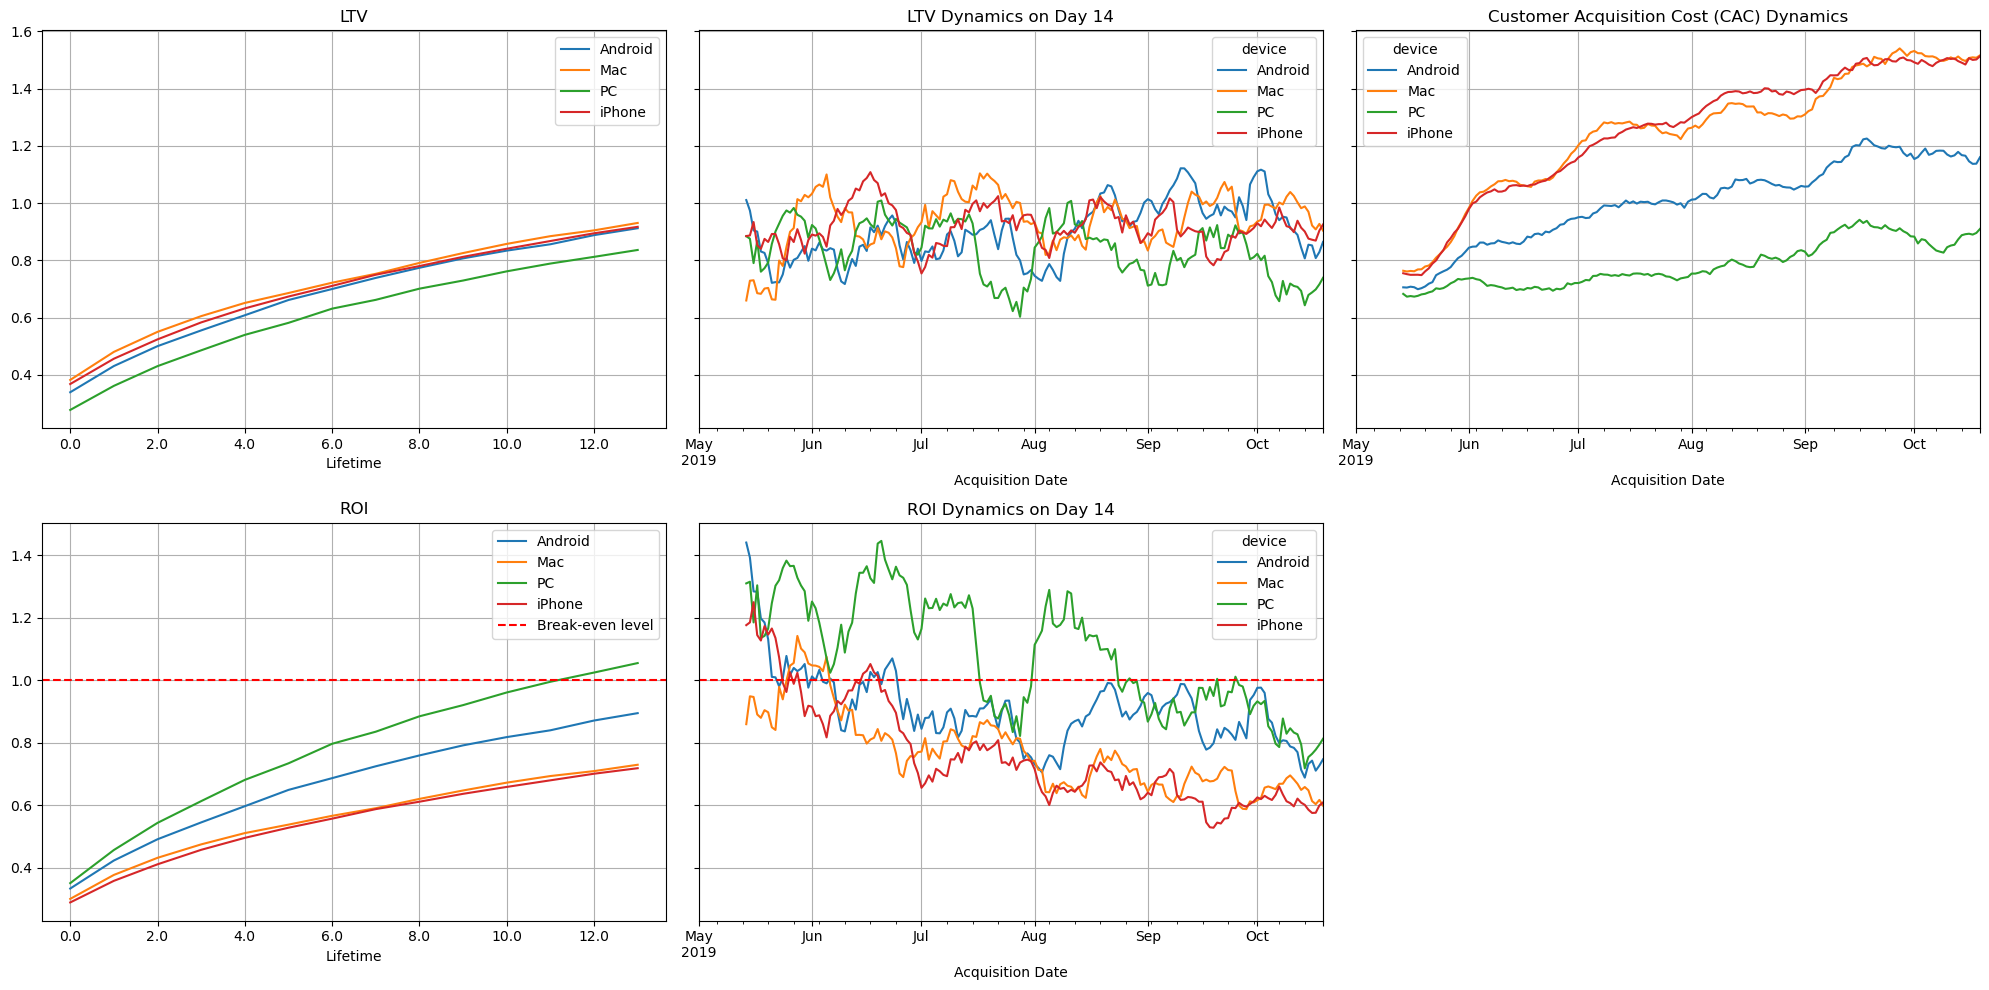

In [38]:
# Check profitability broken down by devices

dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    pay_profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

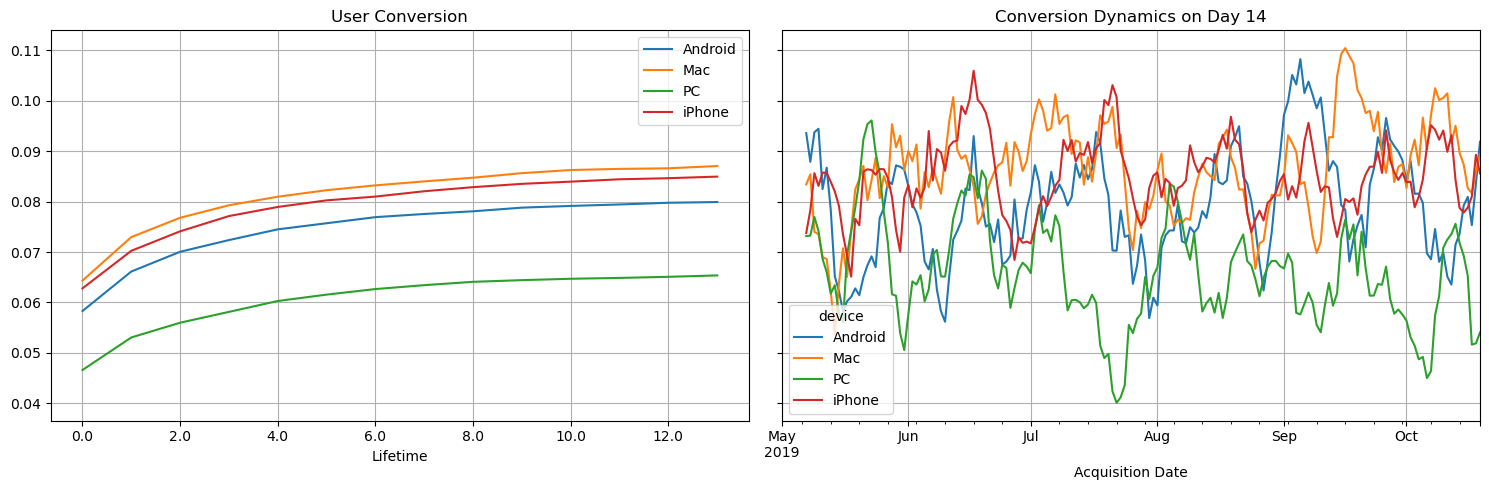

In [39]:
# Analyze conversion broken down by devices

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    pay_profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

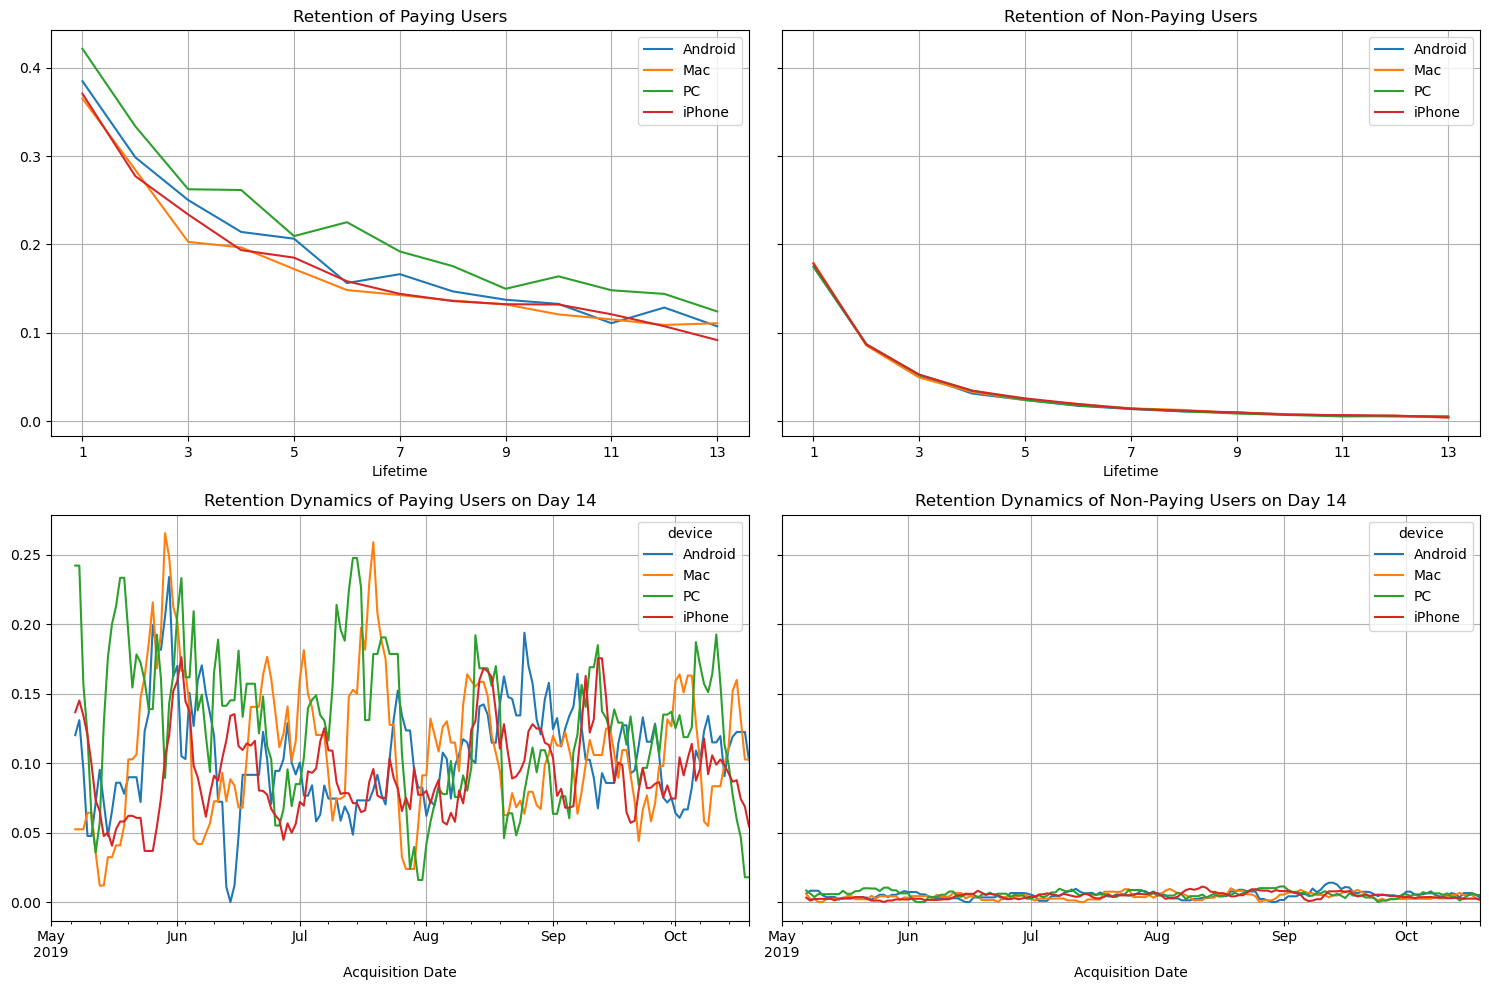

In [40]:
# Analyze retention broken down by devices
retention_raw, retention_grouped, retention_history = get_retention(
    pay_profiles, visits, observation_date, horizon_days, dimensions=dimensions)

plot_retention(retention_grouped, retention_history, horizon_days)

**Conclusion:**

- Users on **PCs** have the lowest LTV and CAC, the **lowest conversion**, but the **highest retention**. ROI is **above the break-even point**, indicating that acquisition costs for this segment are generally justified.

- **iPhone** and **Mac** users show similar trends across all metrics: **highest LTV and highest CAC**, with a sharp spike in June. ROI is **below the break-even point**.

- **Android** users have average values across the board, but ROI is **still below break-even**.

#### Analyze advertising profitability by country. Plot LTV and ROI charts, as well as the dynamics of LTV, CAC, and ROI.

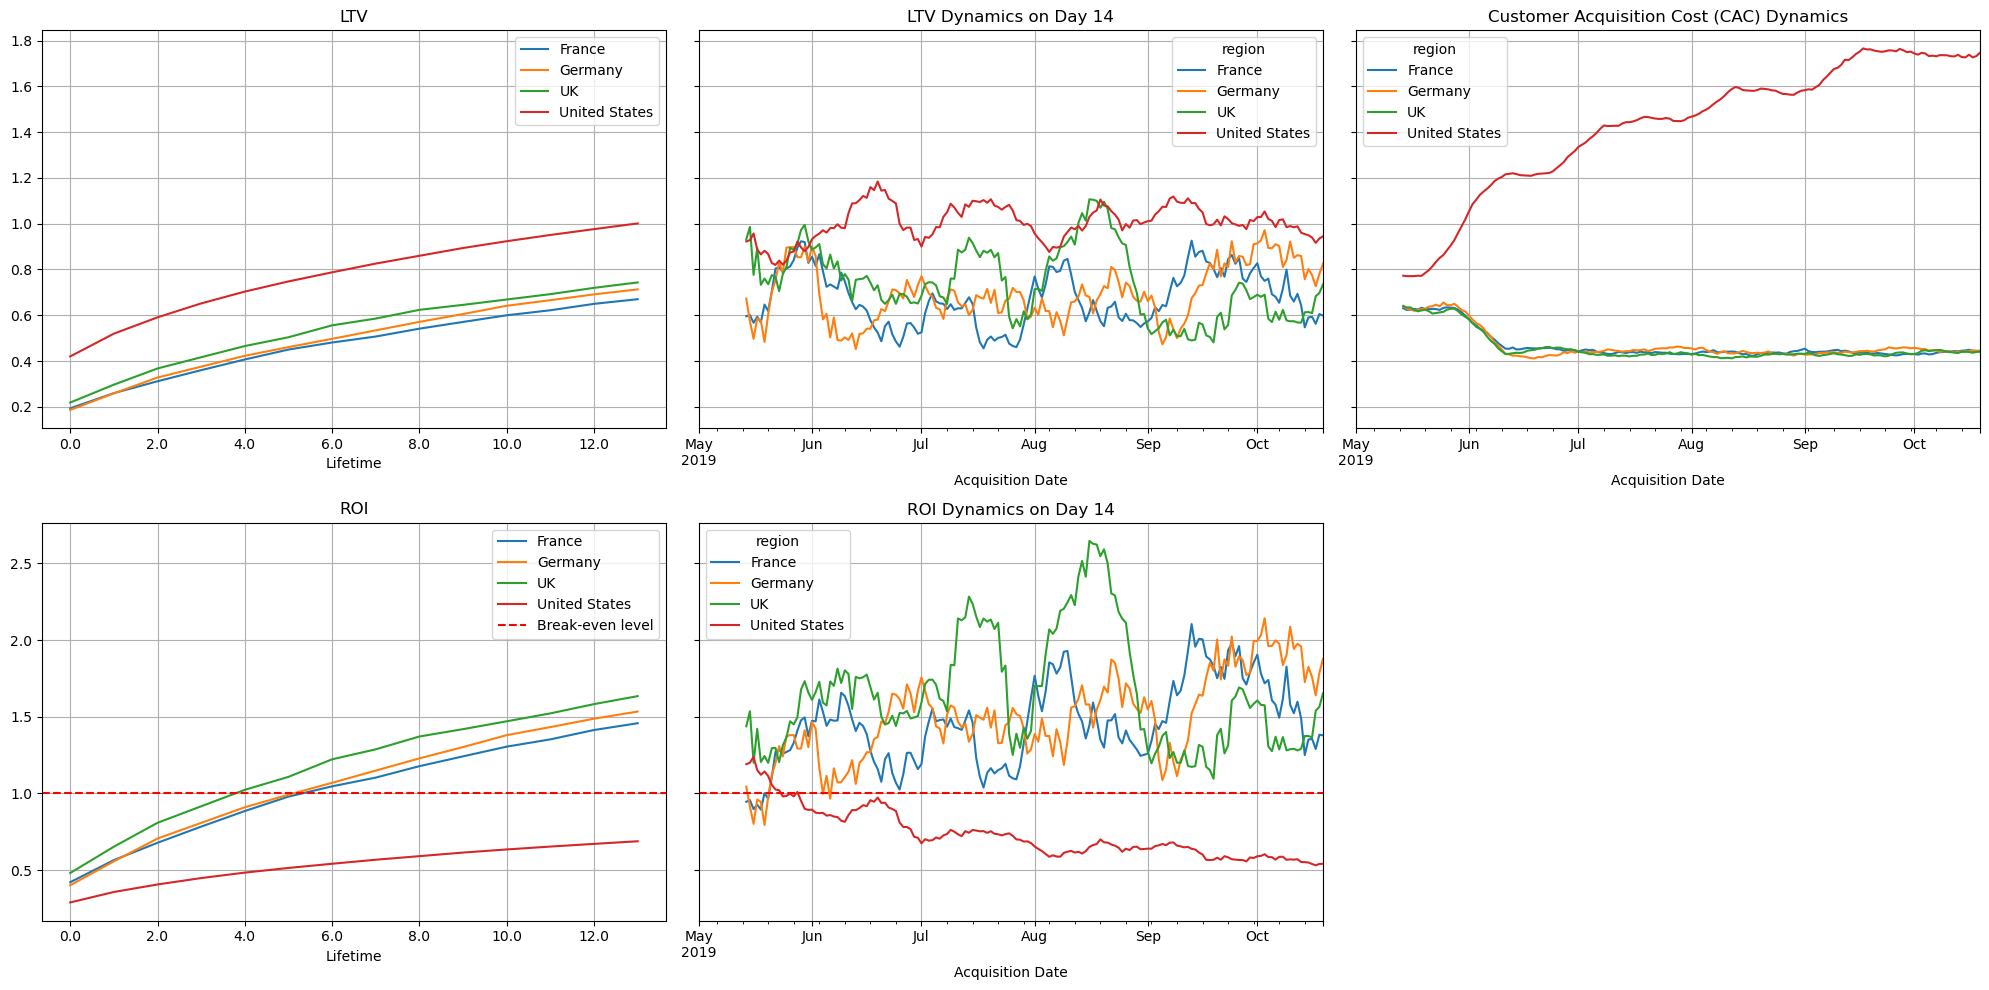

In [41]:
# Analyze profitability broken down by countries

dimensions = ['region']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    pay_profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

The **United States** stands out. It has the highest CAC and very low ROI (costs rise sharply starting in May). ROI dynamics on day 14 are declining.  
Let's find out the reason: is it due to low conversion or poor retention?

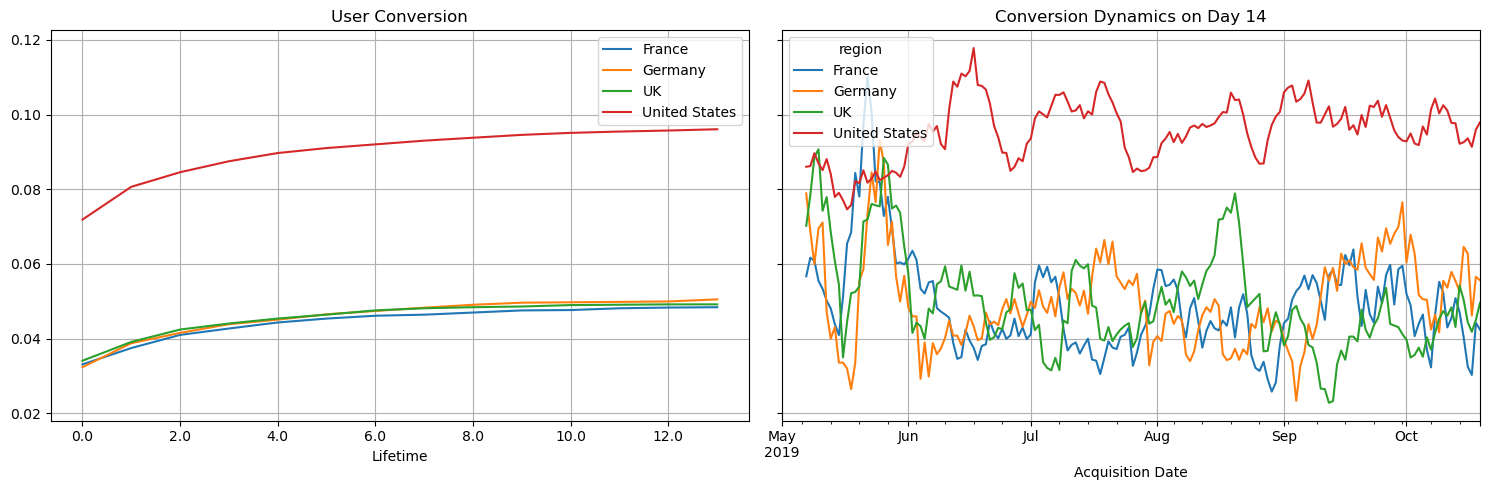

In [42]:
# Analyzing conversion broken down by regions

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    pay_profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

Judging by the charts, American users convert very well. It seems the issue lies in retention.

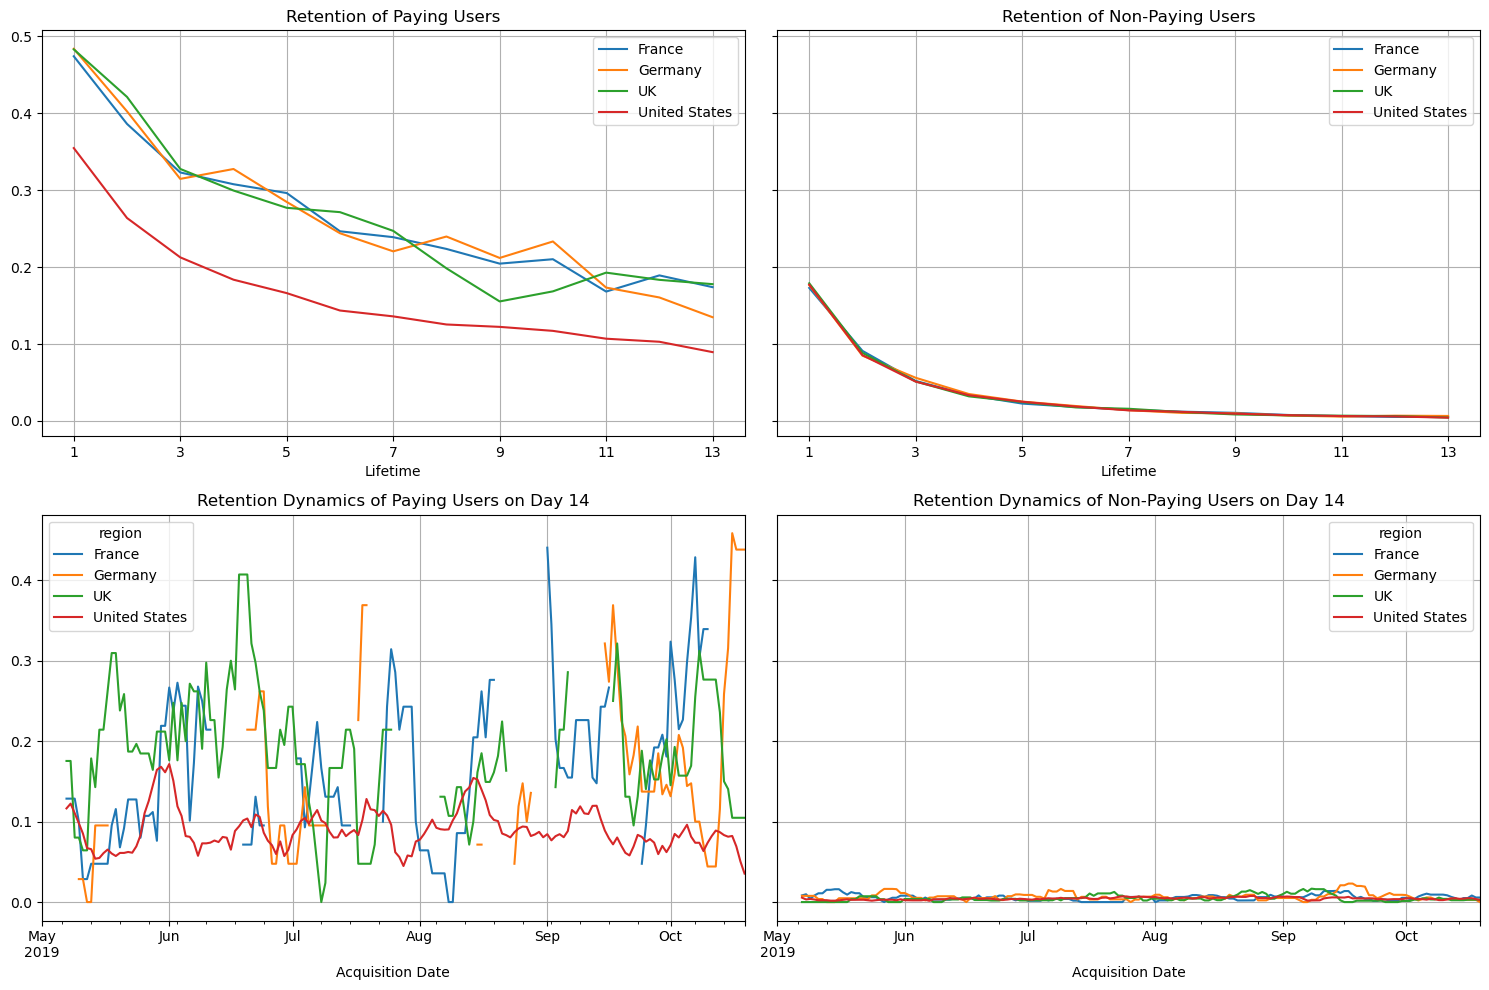

In [43]:
# Analyze retention broken down by countries
retention_raw, retention_grouped, retention_history = get_retention(
    pay_profiles, visits, observation_date, horizon_days, dimensions=dimensions)

plot_retention(retention_grouped, retention_history, horizon_days)

Indeed, users from the United States show consistently poor retention. For paying users, 14-day retention is about **15% lower** compared to other regions.  
This may be due to some kind of **technical issue**.

**Conclusion:**

- In the **United States**, CAC is the highest and ROI is very low (spending spikes starting in May). ROI dynamics by day 14 are declining. The root cause appears to be **poor user retention** in this region. This may be due to various factors such as **high competition**, **issues with product quality or user experience**, **lack of localization**, or **suboptimal targeting strategies**. To address this, the company should **reassess its advertising strategy** in the U.S., potentially optimizing targeting and reallocating budgets to improve cost-efficiency.

- Other regions (**France, Germany, and the UK**) show lower LTV and day-14 LTV dynamics. However, their **user acquisition costs are significantly lower and more stable**, which results in a **positive ROI** (above the break-even point).

#### Analyze advertising profitability by advertising channels. Plot LTV and ROI charts, as well as the dynamics of LTV, CAC, and ROI.

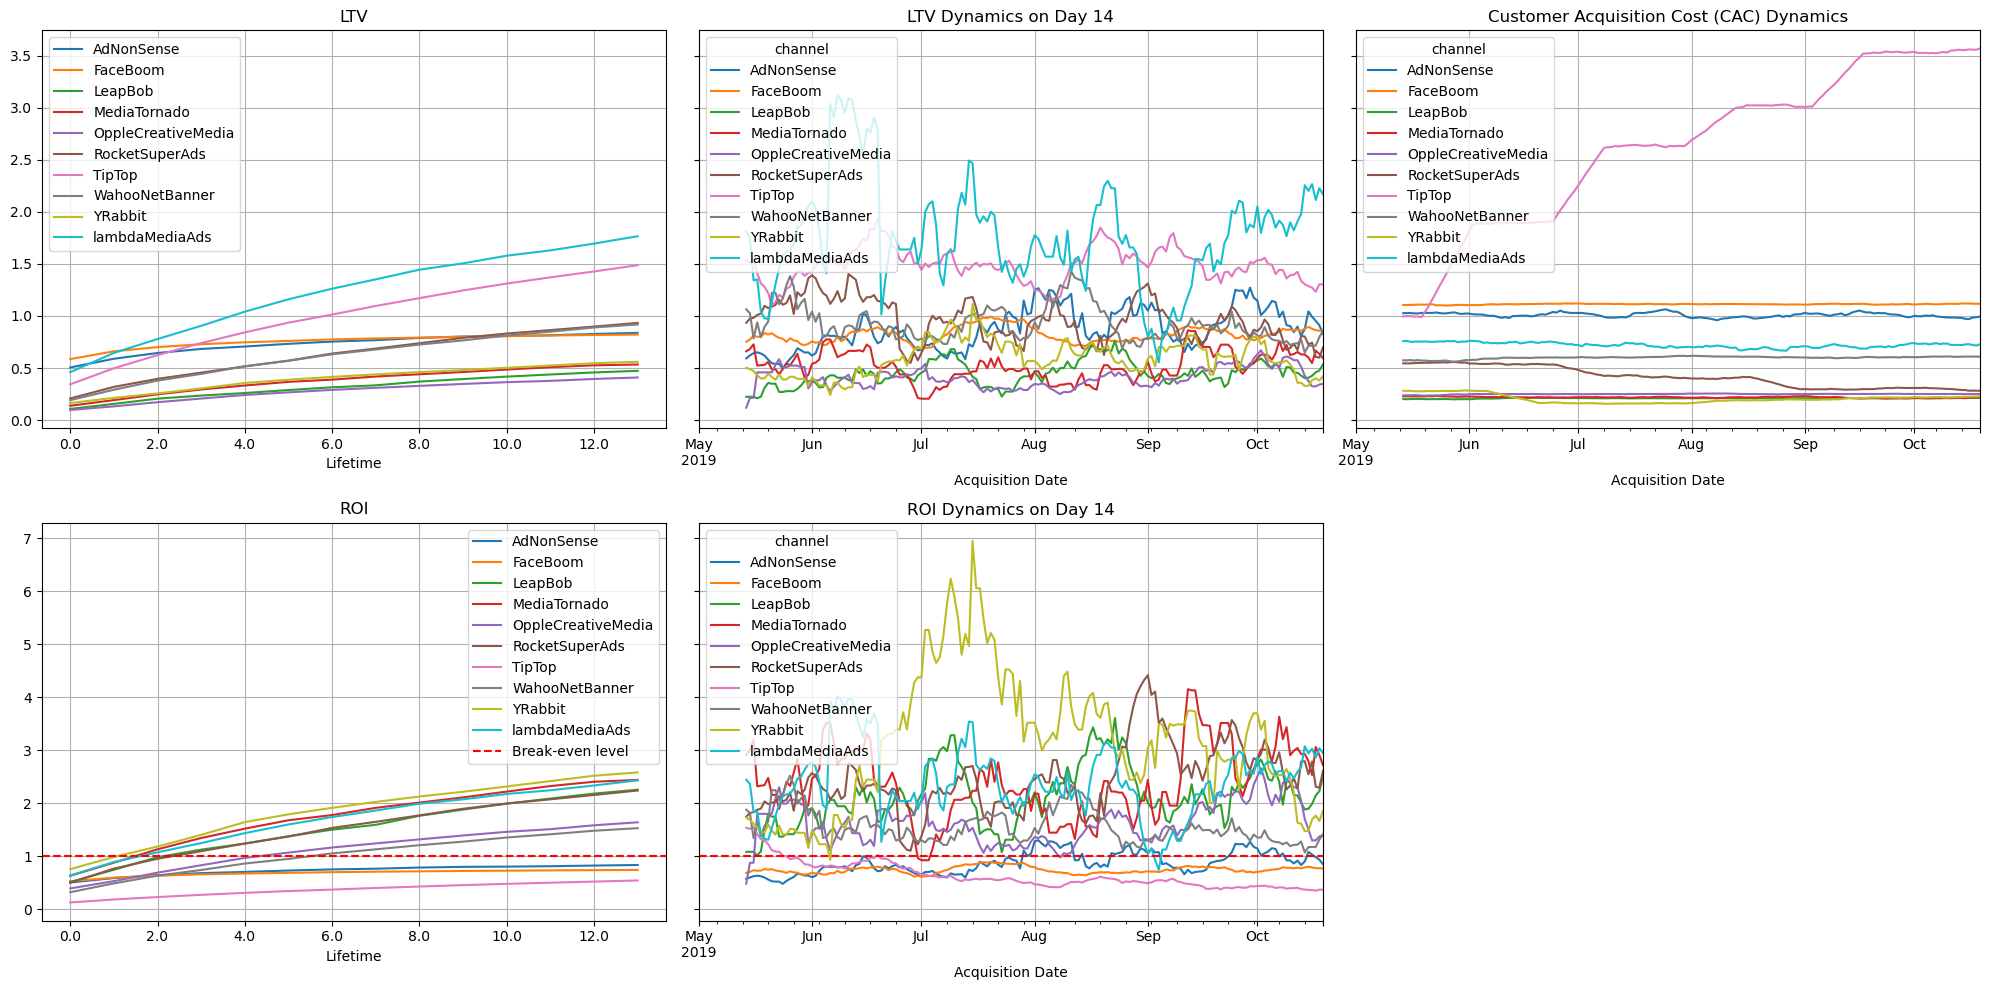

In [44]:
# Analyze profitability broken down by advertising channels

dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    pay_profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

Channels below the break-even point are **TipTop**, **AdNonSense**, and **FaceBoom**.  
**TipTop** has the **highest and continuously rising CAC** and the **lowest ROI**.

It would be useful to check overall conversion and retention.

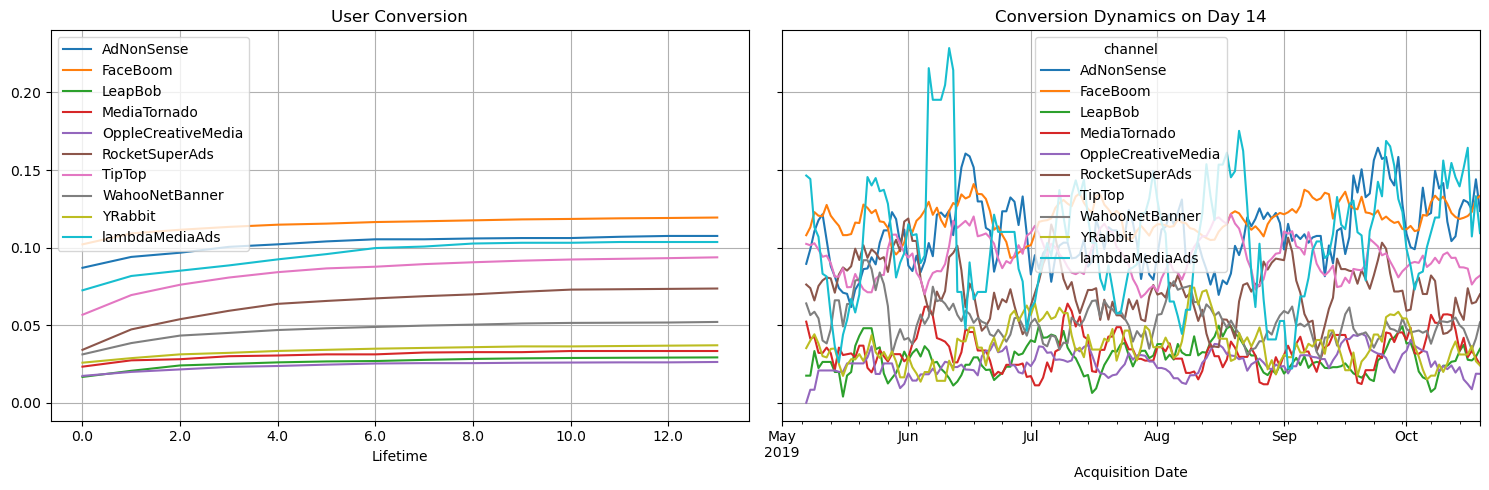

In [45]:
# Analyze conversion broken down by advertising channels

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    pay_profiles, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

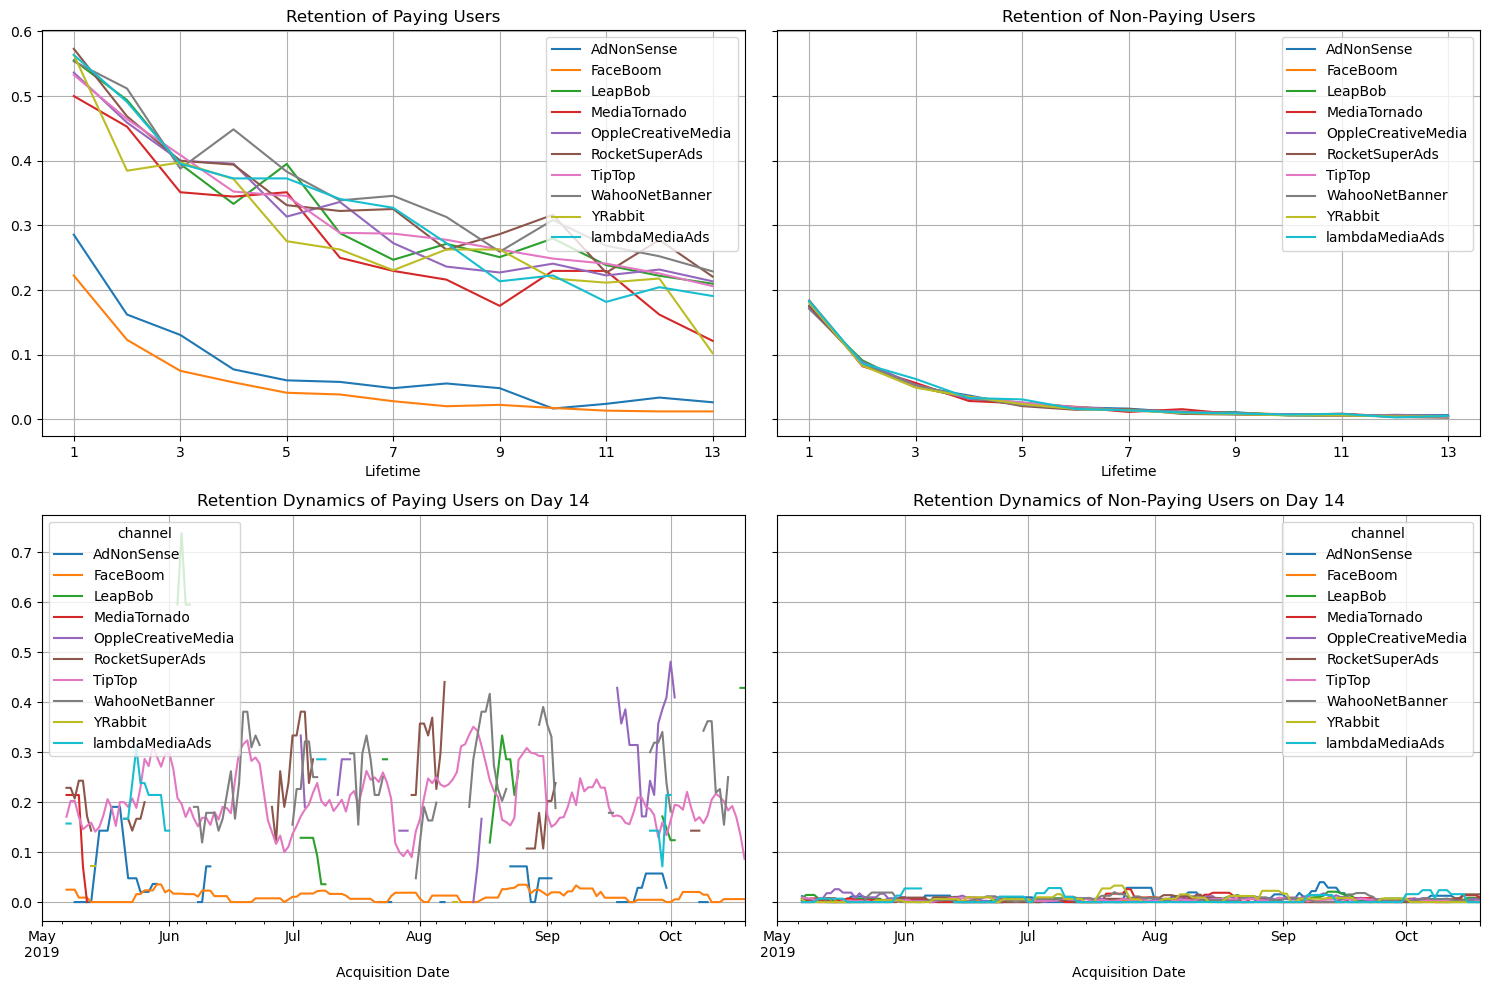

In [46]:
# Analyze retention broken down by advertising channels
retention_raw, retention_grouped, retention_history = get_retention(
    pay_profiles, visits, observation_date, horizon_days, dimensions=dimensions)

plot_retention(retention_grouped, retention_history, horizon_days)

**TipTop** shows solid performance in both conversion and retention.  
However, **AdNonSense** and **FaceBoom** stand out with **significantly lower retention** — about **30–35% lower** than most other channels.

**Conclusion:**

- The channels **below the break-even point** are **TipTop**, **AdNonSense**, and **FaceBoom**.

- **TipTop** shows high LTV, but its efficiency is undermined by a **very high and continuously rising CAC**, resulting in the **lowest ROI**, well below break-even. Since conversion and retention are solid, the issue likely lies in **excessive ad spending**.

- **AdNonSense** and **FaceBoom** are also below break-even. Their LTV is average, CAC is consistently high (second only to TipTop), and they suffer from **very low user retention**.

- The **other channels** demonstrate ROI **above break-even**, with **stable and moderate performance**.

- **yRabbit** shows the **highest ROI**, with ROI dynamics particularly standing out in **June–July**.

- **lambdaMediaAds** has the **highest LTV**, low CAC, and **ROI well above** the break-even level.

Now let's explore the relationships between countries, channels, and devices.  
We'll create a pivot table to show how many users from each country are acquired through each channel.

In [47]:
pivot_reg_chan = profiles.pivot_table(
    index='region',       # Countries
    columns='channel',    # Channels
    values='user_id',     # Number of unique users
    aggfunc='nunique',    # Count unique users
    fill_value=0          # Fill missing values with zeros
)

display(pivot_reg_chan)


channel,AdNonSense,FaceBoom,LeapBob,MediaTornado,OppleCreativeMedia,RocketSuperAds,TipTop,WahooNetBanner,YRabbit,lambdaMediaAds,organic
region,,,,,,,,,,,
France,1366,0,2988,0,2991,0,0,2971,0,742,6392
Germany,1219,0,2519,0,2562,0,0,2579,0,649,5453
UK,1295,0,3046,0,3052,0,0,3003,0,758,6421
United States,0,29144,0,4364,0,4448,19561,0,4312,0,38173


Channels with traffic exclusively from the U.S. are: **FaceBoom**, **TipTop**, **MediaTornado**, **RocketSuperAds**, and **YRabbit**.

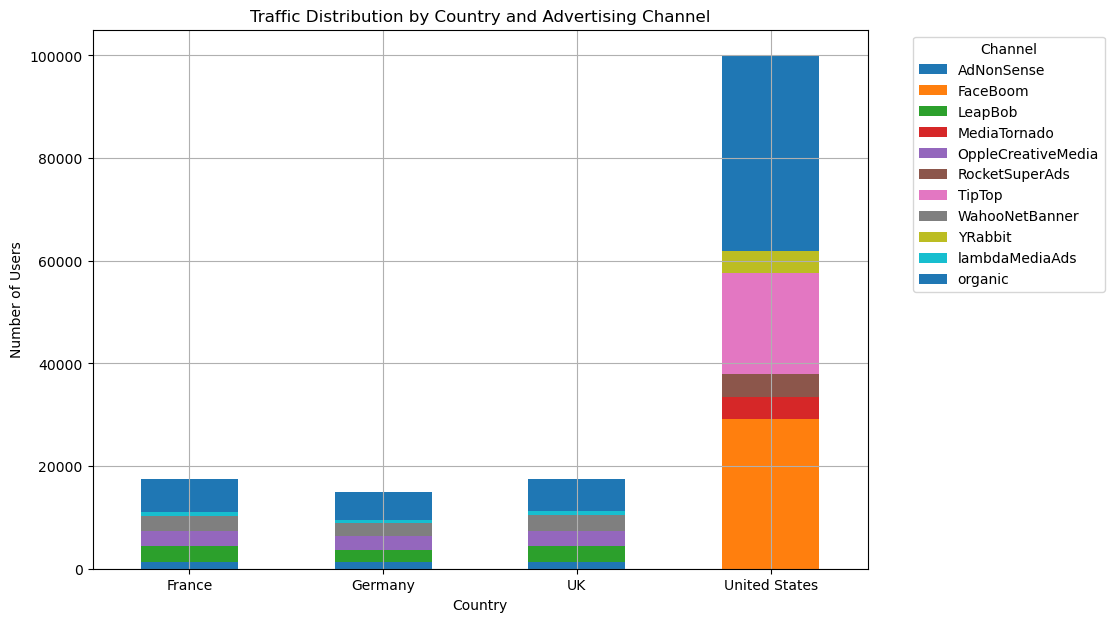

In [48]:
# Plot traffic distribution by country and advertising channel
pivot_reg_chan.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Traffic Distribution by Country and Advertising Channel')
plt.xlabel('Country')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.ylabel('Number of Users')
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


Let's take a closer look at the data for users from the United States.

In [49]:
us_data = pay_profiles[pay_profiles['region'] == 'United States']

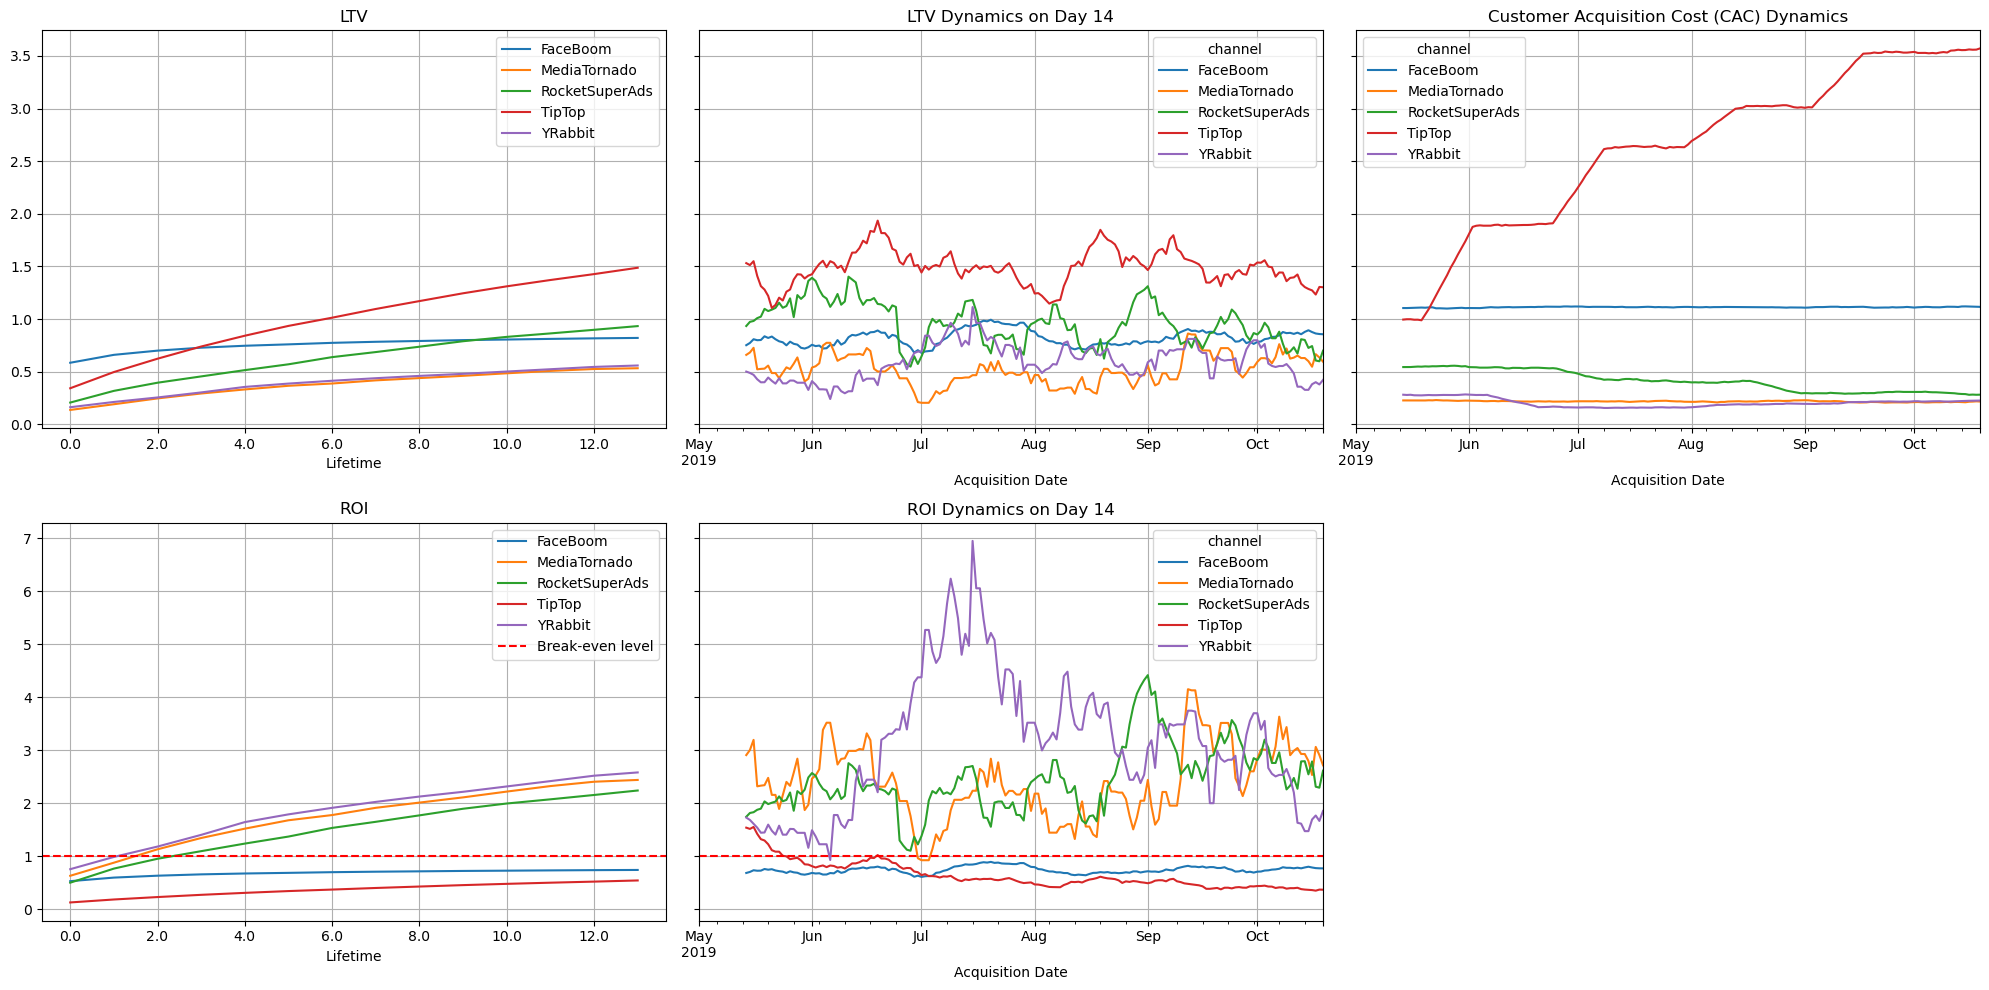

In [50]:
# Analyze profitability broken down by channels

dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    us_data, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

High and rising CAC is observed for **TipTop**, and moderately high but stable CAC for **FaceBoom**. Users from these two channels do not reach the break-even point. Let's investigate the cause.

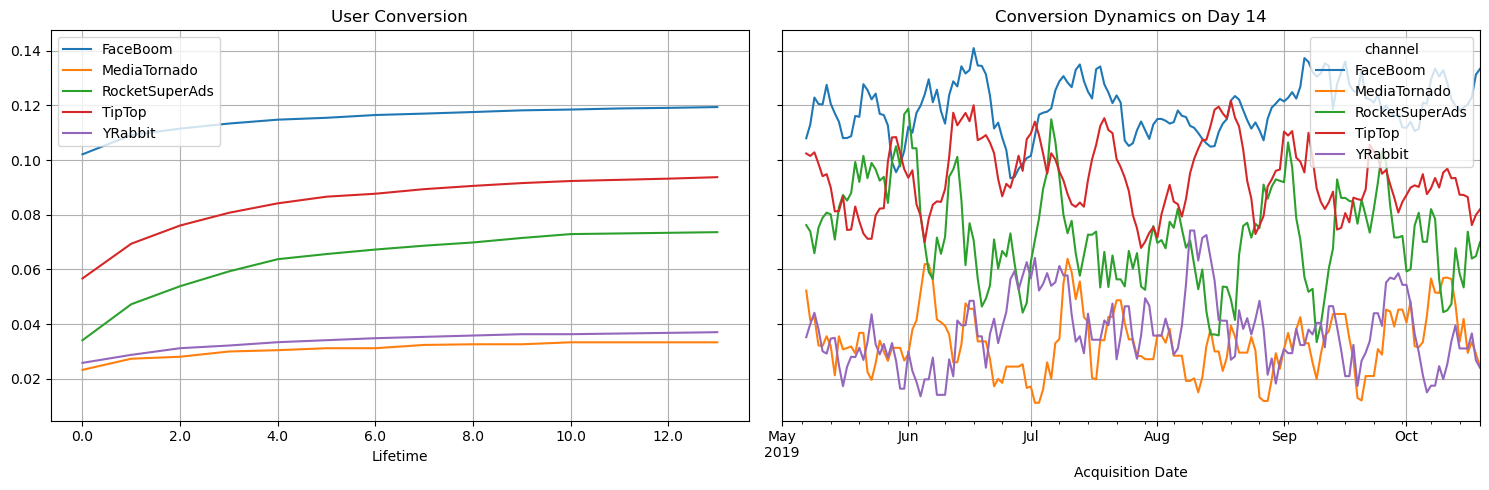

In [51]:
# Check conversion broken down by channels

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    us_data, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

**FaceBoom** has the highest conversion rate, with **TipTop** in second place.

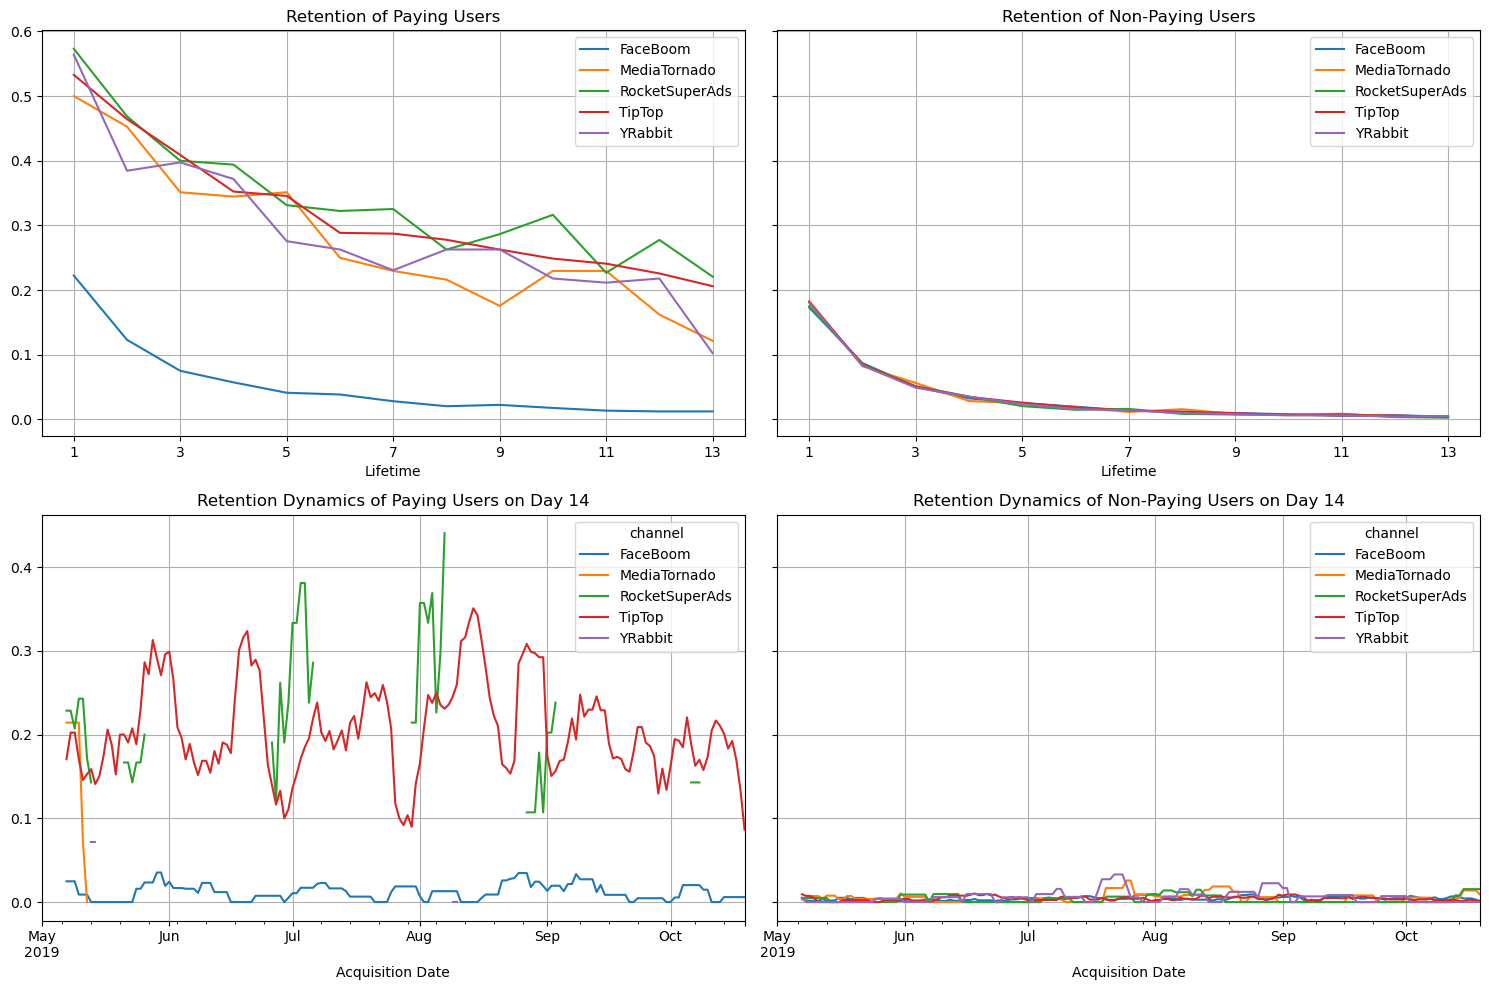

In [52]:
# Check retention broken down by channels
retention_raw, retention_grouped, retention_history = get_retention(
    us_data, visits, observation_date, horizon_days, dimensions=dimensions)

plot_retention(retention_grouped, retention_history, horizon_days)

**FaceBoom** shows very low retention.

We'll also check the **distribution of devices by country**.

In [53]:
# Examine the distribution of devices by country
pivot_device_reg = profiles.pivot_table(
    index='device',      # Devices
    columns='region',    # Countries
    values='user_id',    # Number of unique users
    aggfunc='nunique',   # Count unique users
    fill_value=0         # Fill missing values with zeros
)

display(pivot_device_reg)


region,France,Germany,UK,United States
device,,,,
Android,5252,4440,5141,20199
Mac,1838,1584,1778,24842
PC,6940,5945,7138,10432
iPhone,3420,3012,3518,44529


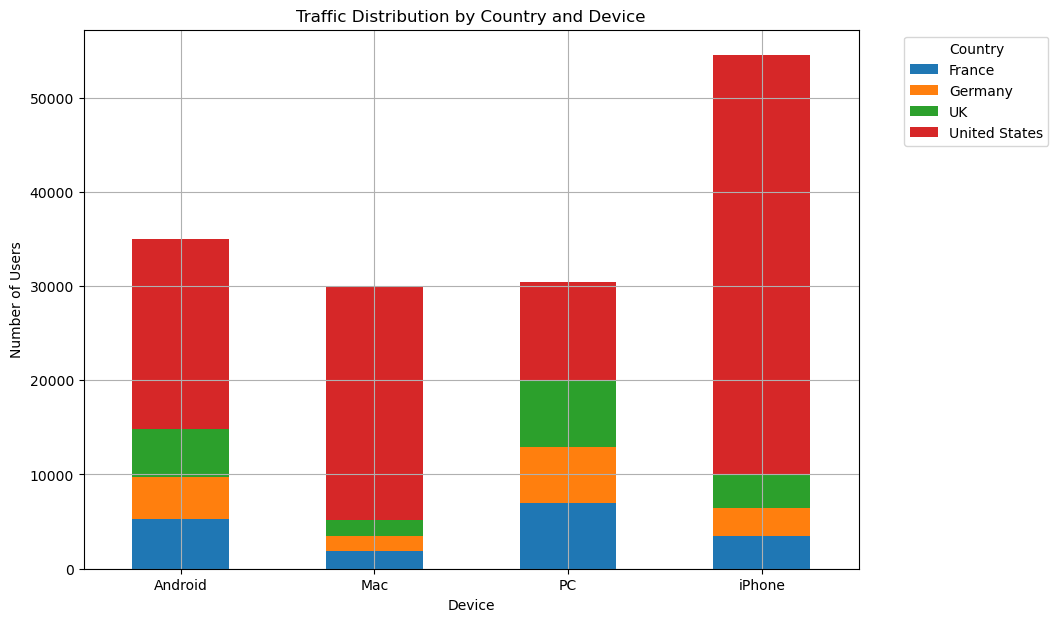

In [54]:
# Plot traffic distribution by country and device
pivot_device_reg.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Traffic Distribution by Country and Device')
plt.xlabel('Device')
plt.xticks(rotation=0)  # Rotate platform names on the X-axis for better readability
plt.ylabel('Number of Users')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


**Conclusion:**

• Channels with US users were examined in more detail. Two channels with ROI below the break-even point were identified: **FaceBoom** (due to significantly lower retention compared to other channels) and **TipTop** (due to lower conversion rates than other channels and a continuously and sharply rising CAC).

• Additionally, the distribution of devices by country was analyzed. US users use PCs the least and iPhones the most. This may explain why only the PC segment shows ROI above the break-even point.

### Conclusion

- **Identify the reasons for the inefficiency of user acquisition.**  
- **Formulate recommendations for the marketing department.**

#### Data Preprocessing with a description of the issues discovered and their solutions

• **Column Names:** Converted to lowercase and spaces replaced with underscores ('_').

• **Data Types:** Date and time columns were converted to datetime format: 'Session Start' and 'Session End' (in the visits table), 'Event Dt' (in the orders table), and 'dt' (in the costs table).

• **Missing Values:** None were found.

• **Duplicates:** Both explicit and implicit duplicate checks were conducted; no duplicates were identified.

#### Findings from the Exploratory Data Analysis

- **User Profiles:**  
  User profiles have been created. The minimum acquisition date is **May 1, 2019**, and the maximum is **October 27, 2019**.

- **Countries:**  
  - **United States:** The highest number of users comes from the United States (100,002), with the highest paying user share of **6.90%**.  
  - **UK:** The second largest, with 17,575 users and a paying share of **3.98%**.  
  - **Germany:** 14,981 users with a paying share of **4.11%**.  
  - **France:** 17,450 users with the lowest paying share at **3.80%**.

- **Devices:**  
  - **iPhone:** Users of iPhone make up the largest audience (54,479) with a high paying user share of **6.21%**.  
  - **Mac:** Despite a smaller user base (30,042), Mac users have the highest paying share at **6.36%**.  
  - **Android:** 35,032 users with a paying share of **5.85%**.  
  - **PC:** 30,455 users with a paying share of **5.05%**.

- **Acquisition Channels:**  
  - **Organic:** The largest number of users (56,439) come organically, but the paying share is very low at **2.05%**.  
  - **FaceBoom:** Attracts 29,144 users, making it the second most popular channel, and it has the highest paying share at **12.2%**, indicating it is the most effective channel.  
  - **TipTop:** Attracts 19,561 users with a paying share of **9.60%** (1,878 users), which is also a high indicator.  
  - **AdNonSense** and **lambdaMediaAds:** Although these channels have one of the lowest numbers of acquired users (3,880 and 2,149 respectively), their paying shares are high at **11.34%** and **10.47%** respectively.

#### Marketing Conclusions

Total marketing expenditure: **105497.3**

**Distribution of expenses by advertising channels:**  
- **TipTop** is the largest source of spending (54,751.30), significantly exceeding expenditures on other channels.  
- **FaceBoom** ranks second with 32,445.60.  
- **WahooNetBanner** and **AdNonSense** have moderate expenses, at 5,151.00 and 3,911.25 respectively.  
- **OppleCreativeMedia**, **RocketSuperAds**, and **LeapBob** incurred spending in the range of 1,800–2,150.  
- **lambdaMediaAds**, **MediaTornado**, and **YRabbit** have the lowest expenditures, varying from 944.22 to 1,557.60.  
- **Organic** has no user acquisition costs (e.g., natural search queries or referral clicks without advertising spend).

**Changes in spending over time:**  
- **TipTop** demonstrates a sharp increase in spending throughout the period, with significant weekly fluctuations and several peaks, notably in June and September.  
- **FaceBoom** shows more consistent spending with only minor fluctuations.

**Cost of acquiring a single user (CAC) from each source:**  
- **TipTop** has the highest average CAC at **2.80**, considerably higher than the other channels.  
- **FaceBoom** and **AdNonSense** also report relatively high CAC values, at **1.11** and **1.01** respectively.  
- **lambdaMediaAds**, **WahooNetBanner**, and the other channels exhibit moderate to low CAC values.

#### Advertising Profitability Conclusions

**Overall Advertising Profitability**  
- Advertising is not profitable. The ROI at the end of the observed period is 80%.  
- CAC is rising significantly, with a particularly sharp spike in June, followed by a more gradual increase.

**User Conversion**  
- Most users convert within the first few days after acquisition, after which conversion slows down but continues to grow.  
- The final conversion rate is around 8%.

**User Retention**  
- Paying users are retained longer and in greater numbers than non-paying users.  
- There are periods of higher retention (e.g., in June and early September) and periods of lower retention (e.g., in June, August, and October).

**Advertising Profitability by Device**  
- PC users show ROI above the break-even point, indicating that the acquisition costs for this segment are generally justified.  
- iPhone and Mac users have the highest LTV and highest CAC (with a sharp spike in June), and their ROI is below the break-even level.  
- Android users show moderate values, but their ROI remains below the break-even point.

**Advertising Profitability by Country**  
- In the United States, CAC is the highest and ROI is very low. The primary reason is the low user retention, which may be caused by various factors such as high competition, quality or user experience issues, insufficient adaptation to cultural specifics, or suboptimal targeting strategies.  
- In other regions, the cost of acquiring users is much lower, and ROI is above the break-even level.

**Advertising Profitability by Advertising Channel**  
- Channels below the break-even point have been identified: **TipTop**, **AdNonSense**, and **FaceBoom**.  
- **TipTop**’s efficiency declines due to a very high and continuously rising CAC. Its conversion is lower than that of FaceBoom, although retention is acceptable, suggesting that the problem lies in excessive advertising costs.  
- **AdNonSense** and **FaceBoom** also show very low user retention.  
- Other channels demonstrate ROI above the break-even level, with stable and moderate results. The highest ROI is observed in **yRabbit** and **lambdaMediaAds**.

**Relationship Between Channels, Countries, and Devices**  
- The distribution of devices and channels by country was also examined.  
- Channels with US users include FaceBoom and TipTop.  
- US users use PCs the least and iPhones the most. This may explain why only the PC segment shows ROI above the break-even level.

#### Recommendations for the Marketing Department

**Optimizing Advertising Spend:**  
- **TipTop:** Consider reducing the budget or implementing more targeted campaigns.  
- **AdNonSense and FaceBoom:** Focus on improving user retention. It may be beneficial to conduct further research to understand why users are leaving the product and to implement measures to enhance the user experience.

**Improving User Retention:**  
- **AdNonSense and FaceBoom:** Conduct additional studies to determine the reasons for low user retention. It is recommended to implement loyalty programs, improve customer support after the first purchase or visit, and increase the frequency and quality of interactions with users.  
- The first few days after user acquisition are critical for conversion, so efforts should be concentrated on maximizing conversion during this period.

**Focusing on the Most Effective Channels:**  
- **yRabbit and lambdaMediaAds:** These channels demonstrate a high ROI. Consider increasing budgets for these channels or leveraging their strategies to optimize performance in other channels.

**Monitoring and Adjusting Strategies:**  
- Regularly monitor key metrics (CAC, LTV, ROI, retention) across all channels and regions. This will enable the rapid identification of issues and allow for timely adjustments to marketing strategies, thereby enhancing overall effectiveness.  
- It is crucial to pay closer attention to marketing performance indicators to utilize the budget more efficiently.